## Сравнительное исследование вакансий аналитиков данных и системных аналитиков на основе данных hh.ru (2024).

1. [**Предобработка данных**](#pre)
    * [Первичный анализ датасета "Аналитик данных"](#da_pre)
    >* [Основные наблюдения после предобработки](#da_res)
    * [Первичный анализ датасета "Системный аналитик"](#sa_pre)
    >* [Основные наблюдения после предобработки](#sa_res)
    * [Поиск и обработка дубликатов](#dubs)
    * [Проверка уникальных значений в категориальных переменных](#cat)
    * [Период сбора данных](#per)
    * [Выводы по первому блоку](#top_res)
---
2. [**Исследовательский анализ данных**](#eda)
    *  [Классификация и распределение грейдов](#grade)
    *  [Распределение количества вакансий и заработной платы](#salary_graph)
    >* [распределение ЗП по грейдам](#salary_res)   
    *  [Доли ваканский по грейдам](#part)   
    *  [Топ работодателей(Аналитик данных)](#top_da)
    >* [Топ работодателей по грейдам](#top_grade) 
    *  [Топ работодателей(Системный аналитик)](#top_sa)
    >* [Топ работодателей по грейдам](#top_grade_sa) 
    *  [Доли предлагаемых вакансий  по графику работы](#format_da)
   >*  [Аналитики данных](#format_da)
   >*  [Системные аналики](#format_sa)   
    *  [Предлагаемый тип занятости](#type)
    *  [Ключевые навыки](#skills)
   >*  [Для грейдов "Аналитик данных"](#da_grade)
   >*  [Для грейдов "Системный аналитик"](#sa_grade)
    *  [Разделение на hard и soft навыки"](#soft)
    

3. [Выводы](#u)


**Цель проекта** 
- Выявить и проанализировать различия между вакансиями для аналитиков данных  и системных аналитиков  на hh.ru по требованиям, условиям и навыкам.
---
**Задачи исследования:**

1. **Классификация вакансий по уровням квалификации (грейдам)**
-  Провести категоризацию вакансий по уровням квалификации (Junior, Junior+, Middle, Senior)
-  Определить долю каждого грейда в общем объёме вакансий для аналитиков данных и системных аналитиков
---
2. **Анализ работодателей и условий труда**
-  Выявить ключевых работодателей, активно нанимающих по каждой из специализаций.
-  Сравнить предлагаемые зарплатные вилки, формат работы и дополнительные бонусы в зависимости от уровня квалификации.
---
3. **Исследование востребованных навыков**
  - Определить ключевые hard skills (технические навыки) и soft skills (гибкие навыки) для каждой специализации
  - Проанализировать, как меняется приоритетность навыков в зависимости от грейда.
---
4. **Формирование выводов и рекомендаций**
-   Создать портрет «идеального кандидата» для вакансий "Аналитик данных" и "Системный аналитик".
-   Разработать практические рекомендации для соискателей по адаптации под требования рынка.
--- 
**Ход исследования:**

Исследование проводилось на основе анализа двух таблиц с данными о вакансиях с сайта hh.ru. На первом этапе данные были проверены на наличие ошибок, дубликатов, аномальных значений и приведены к единому стилю кодирования и типам данных. Это обеспечило высокую точность и достоверность дальнейшего анализа.

Далее был проведён исследовательский анализ данных , включающий визуализацию ключевых метрик с подробными пояснениями и промежуточными выводами. Все графики сопровождались интерпретацией, направленной на выявление закономерностей и тенденций.

В завершение были сделаны обобщающие выводы и даны практические рекомендации для соискателей, желающих эффективно позиционировать себя на рынке труда.
  

**Визуализация**

Для наглядного сравнения двух направлений аналитики я использовал цветовые гааммы:

- <span style="color:#4994c6; font-weight:bold">синяя</span> — для вакансий категории "Аналитик данных"
- <span style="color:#2ca02c; font-weight:bold">зеленая</span> палитра — для вакансий категории "Системный аналитик"


In [1]:
# Необходимые библиотеки.
from nltk import ngrams
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
import re
from tabulate import tabulate
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np
from dataclasses import dataclass
from IPython.display import display, Markdown
from IPython.display import display, HTML

In [2]:
# Загружаем обе талицы.
try:
    df = pd.read_excel('/datasets/Мастерская/vacancies_da (1).xlsx', sheet_name=0, engine='openpyxl')
    df2 = pd.read_excel('/datasets/Мастерская/vacancies_sa.xlsx', sheet_name=0, engine='openpyxl')
    print(f"DA: {len(df)} записей | SA: {len(df2)} записей")
    
except FileNotFoundError as e:
    print(f"Ошибка: файл не найден - {e.filename}")
except Exception as e:
    print(f"Ошибка загрузки: {str(e)}")

DA: 1801 записей | SA: 1915 записей


<a id='pre' a>

#  1. Предобработка данных

In [3]:
# Первый взгляд на датасеты.
display(df.head(2))
df2.head(2)

,id,name,published_at,alternate_url,type,employer,department,area,experience,key_skills,schedule,employment,description,description_lemmatized,salary_from,salary_to,salary_bin,key_skills_from_key_skills_field,hard_skills_from_description,soft_skills_from_description
0,100039284,Junior аналитик данных (исследователь),2024-05-24 09:37:04,https://hh.ru/vacancy/100039284,Открытая,DNS Головной офис,NaN,Владивосток,Junior (no experince),"['Power BI', 'СУБД', 'Python', 'SQL']",Полный день,Полная занятость,наше направление занимается повышением эффекти...,наш направление заниматься повышение эффективн...,60000.0,NaN,ЗП не указана,"SQL, Power BI, Python, СУБД",NaN,NaN
1,100039480,Аналитик данных,2024-05-24 09:39:00,https://hh.ru/vacancy/100039480,Открытая,Комус,NaN,Москва,Junior (no experince),"['MS SQL', 'Работа с базами данных', 'MS Excel']",Полный день,Полная занятость,сегодня комус один из крупнейших поставщиков о...,сегодня комус крупный поставщик офисный товар ...,NaN,NaN,ЗП не указана,"Работа с базами данных, MS SQL, MS Excel",NaN,NaN


,id,name,published_at,alternate_url,type,employer,department,area,experience,key_skills,schedule,employment,description,description_lemmatized,salary_from,salary_to,salary_bin,key_skills_from_key_skills_field,hard_skills_from_description,soft_skills_from_description
0,100046399,Системный аналитик,2024-07-08 10:22:57,https://hh.ru/vacancy/100046399,Открытая,Юрент,NaN,Москва,Middle (3-6 years),"['1С', 'Аналитический склад ума', 'confluence'...",Полный день,Полная занятость,юрент — это новый уровень городской мобильност...,юрент новый уровень городской мобильность круп...,NaN,NaN,ЗП не указана,"SQL, Аналитический склад ума, 1С",confluence,NaN
1,100050107,Бизнес/Системный Аналитик,2024-07-06 17:19:32,https://hh.ru/vacancy/100050107,Открытая,Surf,NaN,Санкт-Петербург,Junior+ (1-3 years),"['Разработка технических заданий', 'Бизнес-ана...",Удаленная работа,Полная занятость,в surf уже 13 лет мы разрабатываем много разны...,surf 13 год разрабатывать разный продукт начин...,NaN,NaN,ЗП не указана,"BPMN, UML, Английский язык, Системный анализ, ...",NaN,Документация


Все колонки имеют корректное название, но не все нужны для исследования.Оставим только те, что нам интересны.

In [4]:
# Часть колонок нам не понадобится. Выкинем их.
cols_to_use = ['id','name','employer','experience','area',
'schedule','employment','salary_from','salary_to','salary_bin',
'key_skills_from_key_skills_field']
# создаеём два новых датасета с вакансиями для аналитиков данных(da) и для системных аналитиков(sa)
da = df[cols_to_use]
sa = df2[cols_to_use]

Используем функцию предобратоки для первичного анализа двух датасетов.

In [5]:
def dataset_overview(data, sample_size=3):
    """
    Полный анализ датасета перед исследованием.
    
    Параметры:
        data: DataFrame - анализируемый датафрейм
        sample_size: int - количество строк для вывода в примере
    
    """
        
    # 1. Заголовок
    display(Markdown("**Первичный анализ**"))
    display(Markdown(f"**Исходные данные:** {data.shape[0]} строк × {data.shape[1]} колонок"))
    
    # 2. Типы данных
    display(data.info())
    display(Markdown("**● Типы данных**"))
    type_counts = data.dtypes.value_counts().to_frame().reset_index()
    type_counts.columns = ['Тип', 'Количество']
    display(type_counts)
    
    # 3. Пропущенные значения
    display(Markdown("**● Пропуски**"))
    missing = data.isna().sum()
    missing_pct = (missing / len(data)) * 100
    missing_report = pd.DataFrame({
        'Колонка': missing.index,
        'Пропущено': missing.values,
        '% Пропусков': missing_pct.round(2).values
    }).query('Пропущено > 0').sort_values('% Пропусков', ascending=False)
    
    if len(missing_report) > 0:
        display(missing_report)
    else:
        display(Markdown("_Пропущенных значений не обнаружено_"))
    
    # 4. Выбросы (для числовых колонок)
    display(Markdown("**● Выбросы**"))
    num_cols = data.select_dtypes(include=np.number).columns
    outliers_report = []
    
    for col in num_cols:
        q1, q3 = data[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        bounds = [q1 - 1.5*iqr, q3 + 1.5*iqr]
        n_outliers = ((data[col] < bounds[0]) | (data[col] > bounds[1])).sum()
        
        if n_outliers > 0:
            outliers_report.append({
                'Колонка': col,
                'Выбросы': n_outliers,
                '% Выбросов': f"{n_outliers/len(data)*100:.1f}%",
                'Границы': f"[{bounds[0]:.2f}, {bounds[1]:.2f}]"
            })
    
    if outliers_report:
        display(pd.DataFrame(outliers_report))
    else:
        display(Markdown("_Выбросы не обнаружены_"))
    
    # 5. Пример данных
    display(Markdown(f"**● Пример ({sample_size} случайные строки)**"))
    display(data.sample(min(sample_size, len(data))))
    
    display(Markdown("**Готово !!**"))
    

<a id='da_pre' a>

### 1.1 Первичный анализ датасета с вакансиями "Аналитик данных".

In [6]:
dataset_overview(da)

**Первичный анализ**

**Исходные данные:** 1801 строк × 11 колонок

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1801 entries, 0 to 1800
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                1801 non-null   int64  
 1   name                              1801 non-null   object 
 2   employer                          1801 non-null   object 
 3   experience                        1801 non-null   object 
 4   area                              1801 non-null   object 
 5   schedule                          1801 non-null   object 
 6   employment                        1801 non-null   object 
 7   salary_from                       348 non-null    float64
 8   salary_to                         228 non-null    float64
 9   salary_bin                        1801 non-null   object 
 10  key_skills_from_key_skills_field  1093 non-null   object 
dtypes: float64(2), int64(1), object(8)
memory usage: 154.9+ KB


None

**● Типы данных**

...

**● Выбросы**

,Колонка,Выбросы,% Выбросов,Границы
0,id,22,1.2%,"[89482421.00, 105390965.00]"
1,salary_from,17,0.9%,"[-31625.00, 239375.00]"
2,salary_to,9,0.5%,"[-87500.00, 372500.00]"


**● Пример (3 случайные строки)**

,id,name,employer,experience,area,schedule,employment,salary_from,salary_to,salary_bin,key_skills_from_key_skills_field
39,100319498,Senior Data Analyst (Pharma) / Старший аналити...,АДВ,Middle (3-6 years),Москва,Полный день,Полная занятость,NaN,NaN,ЗП не указана,NaN
217,101262951,Продуктовый аналитик / Senior product analyst ...,"Лента, федеральная розничная сеть",Middle (3-6 years),Москва,Удаленная работа,Полная занятость,NaN,NaN,ЗП не указана,"ML, Power BI, A/B тесты, SQL, Python, Аналитич..."
1694,99552333,Аналитик данных,СБЕР,Junior+ (1-3 years),Москва,Полный день,Полная занятость,NaN,NaN,ЗП не указана,NaN


**Готово !!**

**Описательная статистика для ваканский <span style="color:#4994c6">**Аналитик данных**</span>:** 

In [7]:
for i in ['salary_from', 'salary_to']:
    print('-' * 30)
    print(f'{"Зарплата до" if i == "salary_to" else "Зарплата от"}')  
    print('-' * 30)
    print(da[i].describe())

------------------------------
Зарплата от
------------------------------
count       348.000000
mean     109525.086207
std       63011.338914
min          50.000000
25%       70000.000000
50%       90000.000000
75%      137750.000000
max      398000.000000
Name: salary_from, dtype: float64
------------------------------
Зарплата до
------------------------------
count       228.000000
mean     153846.714912
std       97255.738565
min       25000.000000
25%       85000.000000
50%      120000.000000
75%      200000.000000
max      497500.000000
Name: salary_to, dtype: float64


В датасете нет ни отрицательных , ни аномально высоких значений. Для уверенности взглянем на **5 наиболее "дорогих" ваканский** и на вакансии с подозрительно **низким  порогом оплаты**.

In [8]:
# Топ 5 сымых высоких ЗП (salary_to)
da[da.salary_to > np.percentile(da[~da.salary_to.isna()].salary_to,98)]

,id,name,employer,experience,area,schedule,employment,salary_from,salary_to,salary_bin,key_skills_from_key_skills_field
212,101257112,Senior Data Analyst / Старший Аналитик Данных,Wannabe,Middle (3-6 years),Москва,Удаленная работа,Полная занятость,280500.0,467500.0,Больше 300 тысяч,"Data Analysis, Python, MS SQL, Black box testi..."
238,101326113,Data Analyst (middle/senior),Fundraise Up,Middle (3-6 years),Москва,Удаленная работа,Полная занятость,299200.0,495550.0,Больше 300 тысяч,"SQL, Английский язык, PostgreSQL, A/B тесты, D..."
556,94100628,Data Analyst (middle/senior),Fundraise Up,Middle (3-6 years),Москва,Удаленная работа,Полная занятость,345950.0,495550.0,Больше 300 тысяч,"SQL, Английский язык, PostgreSQL, A/B тесты, D..."
1139,97041429,Data Analyst / Аналитик Данных,Wannabe,Middle (3-6 years),Москва,Удаленная работа,Полная занятость,280500.0,467500.0,Больше 300 тысяч,"Data Analysis, Python, MS SQL, Black box testi..."
1697,99555701,Data Analyst,Mayflower,Middle (3-6 years),Москва,Полный день,Полная занятость,398000.0,497500.0,Больше 300 тысяч,"Python, A/B тесты, Big Data, Data Analysis, Ta..."


Всё ок. Потолок зарплат реалистичный — ничего подозрительного.

In [9]:
# Топ наименших порогов ЗП (salary_from)
da[da.salary_from < np.percentile(da[~da.salary_from.isna()].salary_from,1 )]

,id,name,employer,experience,area,schedule,employment,salary_from,salary_to,salary_bin,key_skills_from_key_skills_field
98,100568739,Аналитик данных,НКМЗ-ГРУПП,Junior (no experince),Нефтекамск,Полный день,Полная занятость,25000.0,30000.0,Меньше 100 тысяч,"Пользователь ПК, Работа в команде, Умение рабо..."
1102,96829084,"Стажер/Аналитик данных (Python, Power BI)",ППК Фонд развития территорий,Junior (no experince),Москва,Гибкий график,Стажировка,26000.0,26000.0,Меньше 100 тысяч,NaN
1110,96943446,Аналитик данных в отдел развития на маркетплейсах,Репетуев Иван Дмитриевич,Junior (no experince),Москва,Удаленная работа,Полная занятость,50.0,100001.0,От 100 тысяч до 200 тысяч,"Аналитика продаж, Конкурентная аналитика, Анал..."


Есть ошибка при создании вакансии в третей записи. Скорее всего, значение salary_to должно быть на месте значения salary_from, но мы не будем додумывать и просто удалим её. В остальном всё хорошо.

In [10]:
da = da.drop(index=1110)

In [11]:
# Отнимем из верхней графы ЗП нижнюю.
if (da.salary_to - da.salary_from).min() >= 0:
    print('Зарплатные вилки корректны')
else:
    print('не ок')

Зарплатные вилки корректны


<a id='da_res' a>

**Первичная предобработка для data-аналитиков:**
- Колонки по типам и именам в порядке , нерелевантные — удалены.
- В  столбцах с  диапазоном заработной платы много(более 80%) пропусков. Заполнять такие пропуски не свегда благо. Если стратифицированных(по грейдам) наблюдений  будет достаточно, то оставим как есть.
- Удалили одну строку с некоректным значением нижней ЗП.

Найденные выбросы - вполне реалистичные цифры для соискателей претендующих на высокие позиции.
В целом пока всё хорошо.

<a id='sa_pre' a>

### 1.2 Первичный анализ датасета с вакансиями "Системный аналитик"

In [12]:
dataset_overview(sa)

**Первичный анализ**

**Исходные данные:** 1915 строк × 11 колонок

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1915 entries, 0 to 1914
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                1915 non-null   int64  
 1   name                              1915 non-null   object 
 2   employer                          1915 non-null   object 
 3   experience                        1915 non-null   object 
 4   area                              1915 non-null   object 
 5   schedule                          1915 non-null   object 
 6   employment                        1915 non-null   object 
 7   salary_from                       356 non-null    float64
 8   salary_to                         279 non-null    float64
 9   salary_bin                        1915 non-null   object 
 10  key_skills_from_key_skills_field  1274 non-null   object 
dtypes: float64(2), int64(1), object(8)
memory usage: 164.7+ KB


None

**● Типы данных**

...

**● Выбросы**

,Колонка,Выбросы,% Выбросов,Границы
0,id,145,7.6%,"[92338817.50, 109607093.50]"
1,salary_to,1,0.1%,"[-87500.00, 532500.00]"


**● Пример (3 случайные строки)**

,id,name,employer,experience,area,schedule,employment,salary_from,salary_to,salary_bin,key_skills_from_key_skills_field
726,103037375,System Analyst/Системный Аналитик,Aston,Middle (3-6 years),Краснодар,Удаленная работа,Полная занятость,NaN,NaN,ЗП не указана,"UML, MS SQL, REST"
1247,103512729,Специалист по внедрению корпоративной системы ...,Омегасофтвер Рус,Junior+ (1-3 years),Ижевск,Полный день,Полная занятость,50000.0,120000.0,От 100 тысяч до 200 тысяч,NaN
484,102750658,Системный аналитик,Русатом Сервис,Middle (3-6 years),Москва,Полный день,Полная занятость,NaN,NaN,ЗП не указана,"Системный анализ, REST API, gRPC, UML, ArchiMa..."


**Готово !!**

In [13]:
# Топ 5 сымых высоких ЗП (salary_to)
sa[sa.salary_to > np.percentile(sa[~sa.salary_to.isna()].salary_to,99)]

,id,name,employer,experience,area,schedule,employment,salary_from,salary_to,salary_bin,key_skills_from_key_skills_field
1295,103552148,Системный аналитик Senior,Offer Now,Junior+ (1-3 years),Москва,Полный день,Полная занятость,NaN,580000.0,Больше 300 тысяч,NaN
1473,92032011,Старший системный аналитик,БЕТСИТИ,Middle (3-6 years),Москва,Полный день,Полная занятость,NaN,500000.0,Больше 300 тысяч,"UML, Atlassian Confluence, Atlassian Jira, BPM..."
1500,92907892,Старший системный аналитик,БЕТСИТИ,Middle (3-6 years),Ростов-на-Дону,Полный день,Полная занятость,NaN,500000.0,Больше 300 тысяч,"UML, Atlassian Confluence, Atlassian Jira, BPM..."


In [14]:
# Топ наименших порогов ЗП (salary_from)
sa[sa.salary_from < np.percentile(sa[~sa.salary_from.isna()].salary_from,1 )]

,id,name,employer,experience,area,schedule,employment,salary_from,salary_to,salary_bin,key_skills_from_key_skills_field
871,103145776,Проект менеджер / Системный аналитик,Крылов Николай Алексеевич,Junior (no experince),Москва,Удаленная работа,Частичная занятость,20000.0,20000.0,Меньше 100 тысяч,"Atlassian Jira, Trello, Atlassian Confluence, ..."
1152,103462033,"Системный аналитик 1С (стажер, 0.5 ставки)",Компания Апогей (1С-франчайзи),Junior (no experince),Красноярск,Гибкий график,Полная занятость,30000.0,40000.0,Меньше 100 тысяч,"Работа с большим объемом информации, Аналитиче..."
1323,103571805,Системный аналитик,Сибдиджитал,Junior (no experince),Улан-Удэ,Полный день,Полная занятость,30000.0,60000.0,Меньше 100 тысяч,"SQL, Бизнес-анализ, BPMN, UML, Разработка техн..."
1470,91944373,Системный Аналитик Middle/Senior,Datanomica,Senior (6+ years),Москва,Удаленная работа,Полная занятость,280.0,340000.0,Больше 300 тысяч,"JSON API, XML, JSON, Agile, Java, SQL, Kafka"



Всего одна ошибка в записи. Удалим по схожей логике.

In [15]:
# Удаляем запись по индексу
sa = sa.drop(index=1470)

Также вычтем нижний порог зарплаты из верхнего и посмотрим нет ли отрицательных значений.

In [16]:
# Отнимем из верхней графы ЗП нижнюю.
if (sa.salary_to - sa.salary_from).min() >= 0:
    print('Зарплатные вилки корректны')
else:
    print('не ок')

Зарплатные вилки корректны


<a id='sa_res' a>

**Первичная предобработка для системных аналитиков:**
- Колонки в порядке.
- Лишь одно наблюдение с выбросом по верхней ЗП и одно некорректное значение в нижнем диапазоне, которые мы удалили.
- Колонки с диапазоном зарплат заполнены на ~17% и на ~70% по скилам .
В остальном тоже всё ок.

<a id='dubs' a>

### 1.3 Проверка дубликатов

Вижу смысл искать дубликаты только по айдишникам, так как компания может открыть несколько схожих вакансий с идентичными параметрами.

In [17]:
# У аналитиков
print(f'Дубликатов  {da.id.duplicated().sum()}')

Дубликатов  0


In [18]:
# У системников
print(f'Дубликатов  {sa.id.duplicated().sum()}')

Дубликатов  0


<a id='cat' a>

### 1.4 Проверка уникальных значений в категориальных переменных

Проверим уникальные категориальные значения  в колонках необходимых для исслоедования.

In [19]:

def cat_unique_check(df, cat_columns, 
                     color_header='\033[1m', 
                     color_colname='\033[94m\033[1m', 
                     color_reset='\033[0m',
                     data_name='data'):
    """
    Анализирует и выводит в отформатированном виде уникальные значения 
    указанных категориальных переменных.
    
    Параметры:
    - cat_columns: список категориальных колонок
    - color_header: цвет заголовка
    - color_colname: цвет названия колонки
    - data_name: название датастета
    """
    console_width = 126

    print("┌" + "─" * (console_width - 2) + "┐")
    print(f"│ {color_header}{data_name:^{console_width-2}}{color_reset}│")
    print("├" + "─" * (console_width - 2) + "┤")

    for col in cat_columns:
        uniques = df[col].unique()
        values_str = ", ".join(str(x) for x in uniques[:5])
        
        if len(uniques) > 5:
            values_str += f", ... (всего: {len(uniques)})"        
        
        # Цветное название колонки
        print(f"│ {color_colname}{col:<15}{color_reset} │ {values_str:<{console_width-25}}│")        
        print("│" + " " * (console_width - 2) + "│")
        print("├" + "─" * (console_width - 2) + "┤")   

    print("└" + "─" * (console_width - 2) + "┘")

In [20]:
cat_unique_check(da, ['employment','experience','schedule','salary_bin','employer'], data_name='Аналитики данных')

┌────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│                                                       Аналитики данных                                                      │
├────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ employment      │ Полная занятость, Стажировка, Частичная занятость, Проектная работа                                  │
│                                                                                                                            │
├────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ experience      │ Junior (no experince), Junior+ (1-3 years), Middle (3-6 years), Senior (6+ years)                    │
│                                                                                                                     

In [21]:
cat_unique_check(sa,['employment','experience','schedule','salary_bin','employer']
                 ,color_colname='\033[92m\033[1m', data_name='Системные аналитики') 

┌────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│                                                     Системные аналитики                                                     │
├────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ employment      │ Полная занятость, Стажировка, Частичная занятость, Проектная работа                                  │
│                                                                                                                            │
├────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ experience      │ Middle (3-6 years), Junior+ (1-3 years), Senior (6+ years), Junior (no experince)                    │
│                                                                                                                     

Всё в порядке !

<a id='per' a>

**Вакансии за период:**

In [22]:
# Для аналитиков данных
display(Markdown("**Период наблюдений для аналитиков данных:**"))
display(Markdown(f"- **Начало периода:** {df.published_at.min().strftime('%Y-%m-%d')}"))
display(Markdown(f"- **Конец периода:** {df.published_at.max().strftime('%Y-%m-%d')}"))
display(Markdown(f"- **Длительность:** {(df.published_at.max() - df.published_at.min()).days} дней"))

# Для системных аналитиков
display(Markdown("<br>**Период наблюдений для системных аналитиков:**"))
display(Markdown(f"- **Начало периода:** {df2.published_at.min().strftime('%Y-%m-%d')}"))
display(Markdown(f"- **Конец периода:** {df2.published_at.max().strftime('%Y-%m-%d')}"))
display(Markdown(f"- **Длительность:** {(df2.published_at.max() - df2.published_at.min()).days} дней"))

**Период наблюдений для аналитиков данных:**

- **Начало периода:** 2024-02-13

- **Конец периода:** 2024-06-11

- **Длительность:** 118 дней

<br>**Период наблюдений для системных аналитиков:**

- **Начало периода:** 2024-06-27

- **Конец периода:** 2024-07-09

- **Длительность:** 12 дней

---

<a id='top_res' a>

**Выводы по предобработке:**
1. **Структура данных**

- В датасетах ~2000 записей и по 20 колонок. 
- Все колонки имеют правильное название и типизированы.
- Нерелевантные и дублирующие колонки были отброшены к этапу исследования.
- Уникальные значения в категориальных переменных необходимых для анализа корректны.

2. **Пропуски в данных**
- Столбец с навыками заполнен примерно на 70% в обоих датасетах, что составляет более 1000 записей - этого объема должно хватить для проведения полноценного анализа.
- Хуже с переменными по диапазонам ЗП(около 300 записей в обеих датасетах), но это вся совокупность, что у нас есть. Заполнение пропусков переменных с заработной платой, не считаю благом.

3. **Выбросы и аномалии**
- Удалено по одной записи в каждом датафрейме с некорретной информацией по ЗП.

4. **Дубликаты**
- Явных дубликатов в данных нет. Поиск неявных произведённых по идентификаторам также результатов не принёс.

В целом датасеты очень чистые, наши правки минимальны. Данные готовы для исследования.

<a id='eda' a>

## 2 Исследовательский анализ данных

<a id='grade' a>

### 2.1 Классификация и рапределение грейдов.

In [23]:
# Создадим дополнительыне переменные с ЗП, высчитав среднее в зарплатной вилке
da['avg_salary'] = (da.salary_from + da.salary_to) / 2
sa['avg_salary'] = (sa.salary_from + sa.salary_to) / 2

<span style="color:#4994c6">**Аналитики данных**</span>

In [24]:
#Количество наблюдений с известными нижней планкой заработной платы data-аналитиков
result = da[da.salary_from.notna()].groupby('experience').salary_from.count()
result_df = result.to_frame(name='Количество')
result_df['Процент'] = (result / result.sum() * 100).round(1).astype(str) + '%'
result_df.style.background_gradient(cmap='Blues')

,Количество,Процент
experience,,
Junior (no experince),55,15.9%
Junior+ (1-3 years),214,61.7%
Middle (3-6 years),75,21.6%
Senior (6+ years),3,0.9%


In [25]:
#Количество наблюдений с известными нижней планкой заработной платы data-аналитиков
result = sa[sa.salary_from.notna()].groupby('experience').salary_from.count()
result_df = result.to_frame(name='Количество')
result_df['Процент'] = (result / result.sum() * 100).round(1).astype(str) + '%'
result_df.style.background_gradient(cmap='Greens')

,Количество,Процент
experience,,
Junior (no experince),44,12.4%
Junior+ (1-3 years),168,47.3%
Middle (3-6 years),135,38.0%
Senior (6+ years),8,2.3%


Сразу отмечу, что в датасете почти не представлены вакансии Senior с известными зарлатными вилками. Этих выборок недостаточно для полноценного анализа и статистических выводов.

<a id='salary_graph' a>

### 2.2 Графики распределения количества ваканский и заработной платы:

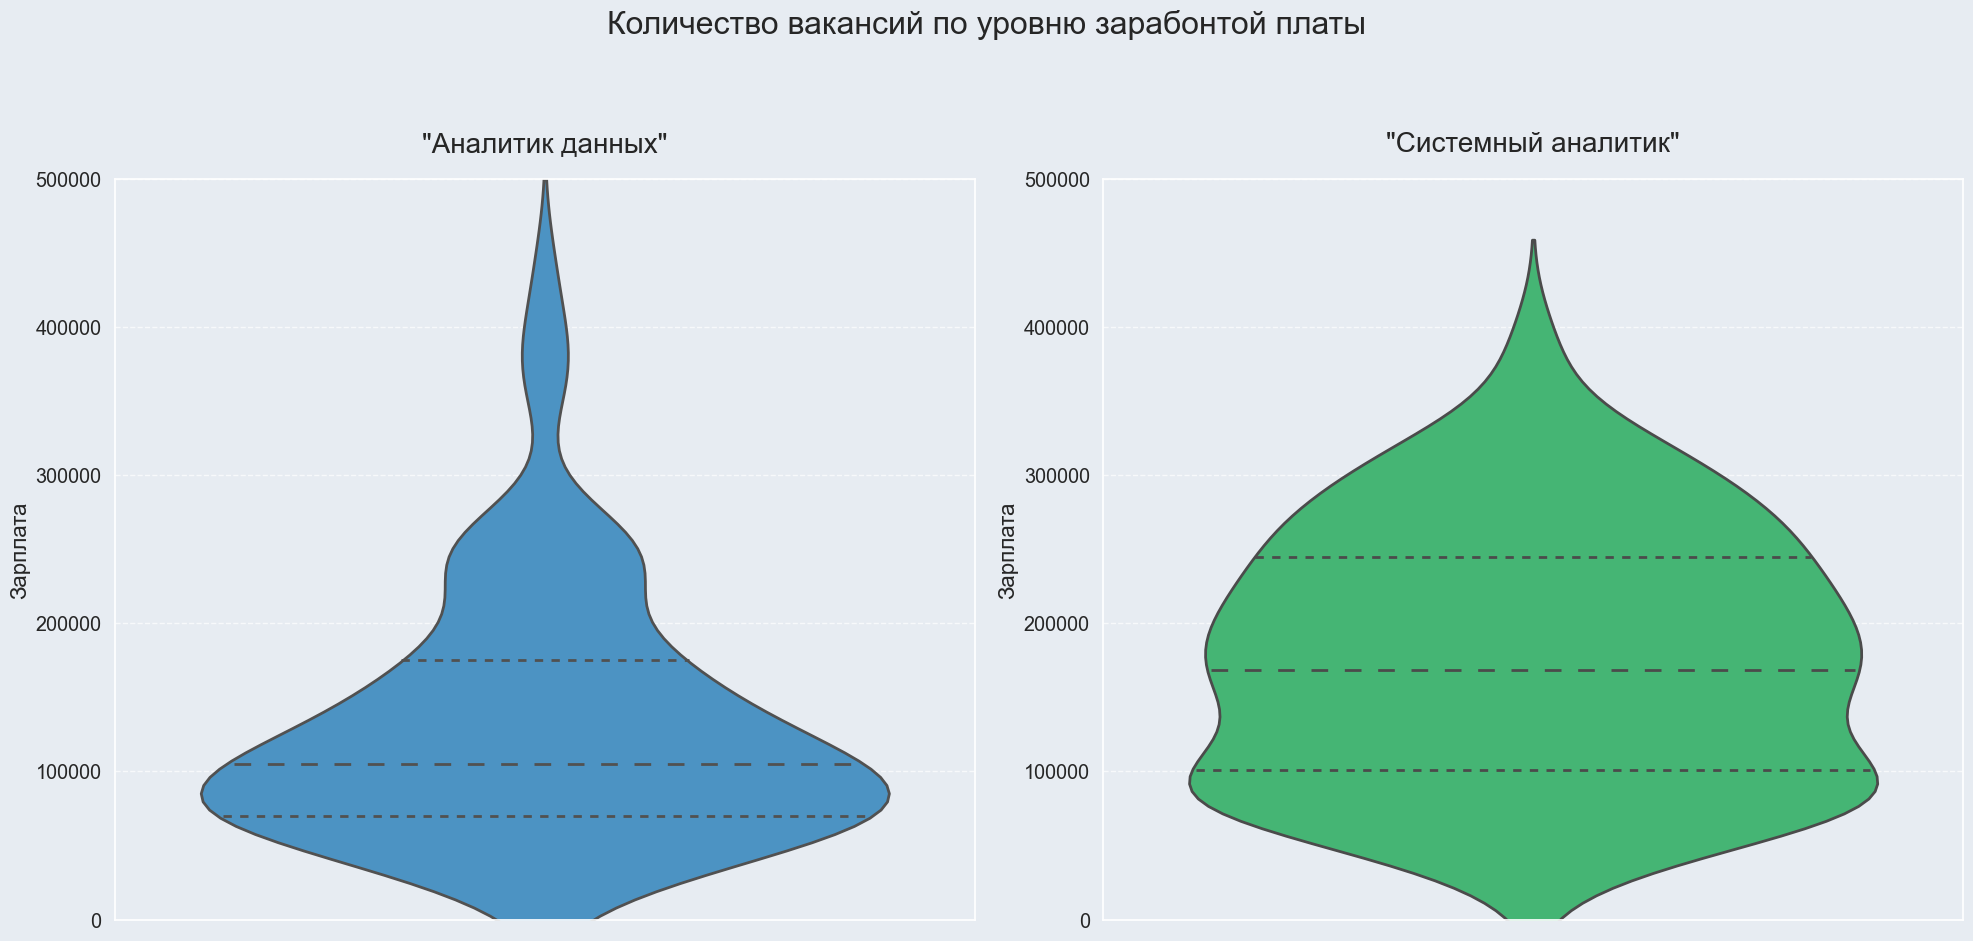

In [26]:
# Настройка стиля графиков
sns.set(rc={'axes.facecolor':'#e7ecf2', 'figure.facecolor':'#e7ecf2'}, 
        font_scale=1.3)

# Создаем фигуру с двумя графиками рядом
fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.suptitle('Количество вакансий по уровню зарабонтой платы', y=1.05, fontsize=23)  # Общий заголовок

# Цвета cиний и зелёный
palette = ["#4994c6", "#42b874"]
datasets = [
    (da, "Аналитик данных"),  # Первый датафрейм и его название
    (sa, "Системный аналитик")  # Второй датафрейм и его название
]

for i, (data, title) in enumerate(datasets):
    sns.violinplot(y=data['avg_salary'], 
                   ax=axes[i],
                   color=palette[i],
                   inner="quartile",
                   linewidth=2,  
                   saturation=0.95)  
    
    # Настройка оформления
    axes[i].set_title(f'"{title}"', fontsize=20, pad=20)
    axes[i].set_ylabel('Зарплата', fontsize=16)
    axes[i].set_xlabel('')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7) 
    axes[i].set_ylim(0,500000) # share y



plt.tight_layout()
plt.show()

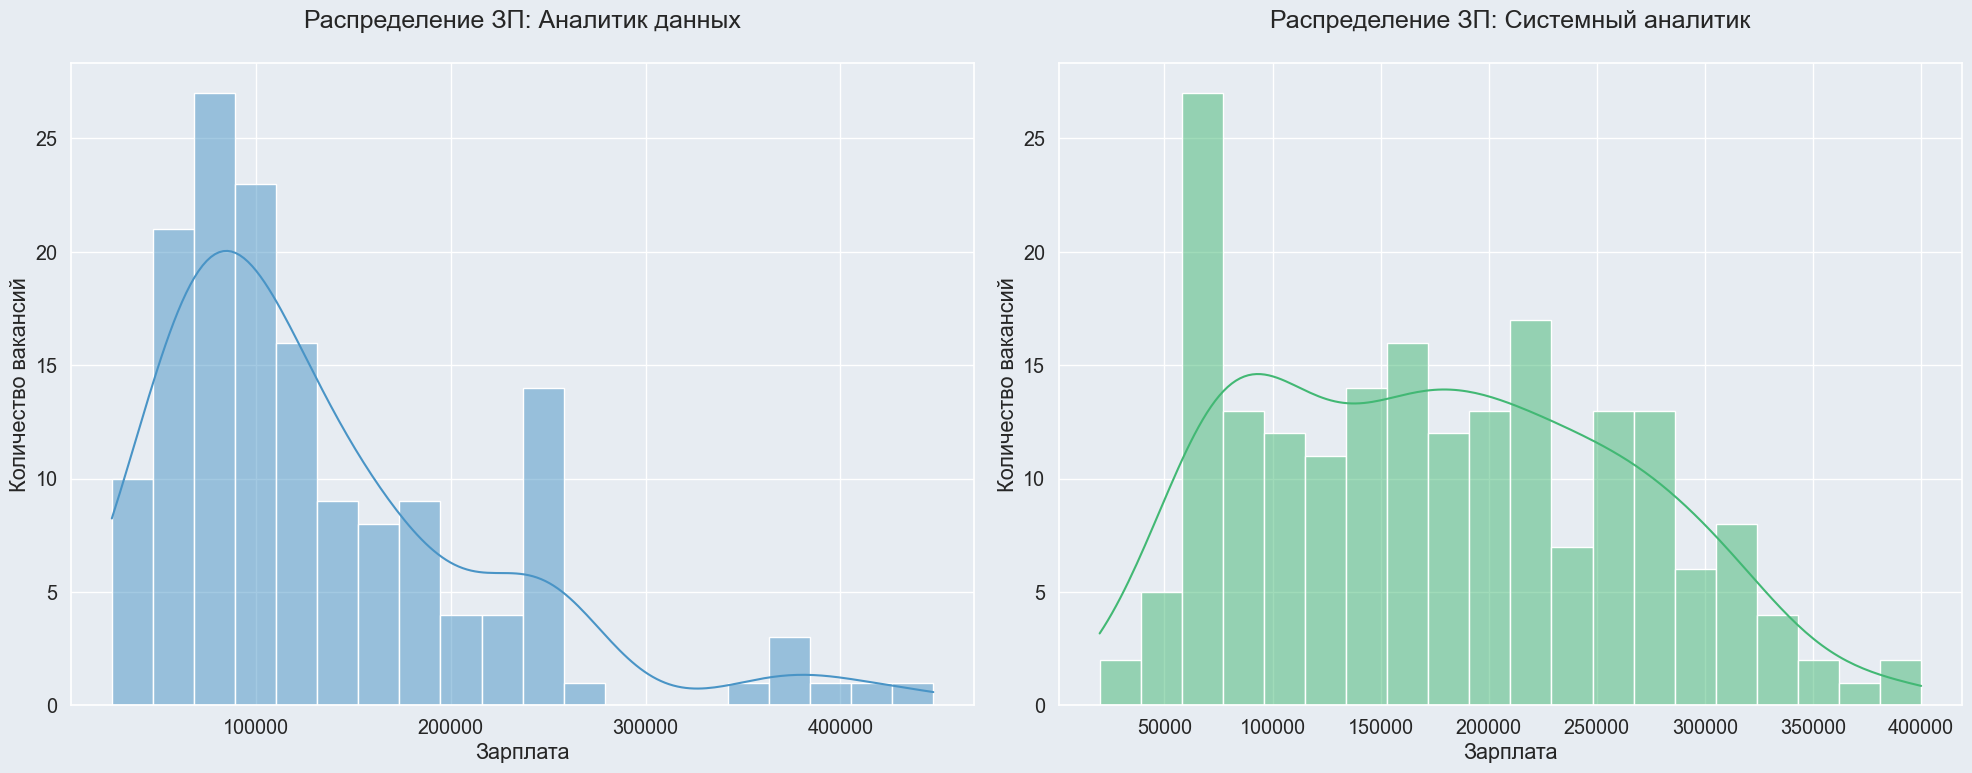

In [27]:
# Настройка стиля графиков
sns.set(rc={'axes.facecolor':'#e7ecf2', 'figure.facecolor':'#e7ecf2'}, 
        font_scale=1.3)
# Создаем фигуру с двумя графиками рядом и персонифицируем цвета
colors = ["#4994c6", "#42b874"]
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
# Список датафреймов и их названий для подписей

datasets = [(da, "Аналитик данных"), (sa, "Системный аналитик")]
# Строим гистограммы для каждого датафрейма
for i, (df, title) in enumerate(datasets):
    sns.histplot(df['avg_salary'], bins=20, ax=axes[i], kde=True, color=colors[i])
    axes[i].set_title(f'Распределение ЗП: {title}',size=18,pad=25)
    axes[i].set_xlabel('Зарплата')
    axes[i].set_ylabel('Количество вакансий')

plt.tight_layout()



<a id='salary' a>

**Анализ распределения количества ваканский и заработной платы:**

**Для аналитиков данных:**

- Первый кластер ярко выражен в диапазоне 80-120 тыс. руб.
- Второй кластер менее выражен в  220-240 тыс. руб
- Медиана лежит в районе 110 т.р.

**Для системных аналитиков:**

Заработная плата для аналитиков имеет более равномерное распределение :

- С пиком в диапазоне 60-80 тыс. рублей
- Равномерностью в диапазоне 100 - 280 тыч. рублей.
- Медиана у системников знасительно выше и находится в районе 160 т.р.

Кластеризация значений отражает зависимость от грейдинговой системы компаний, где каждый пик соответствует определенному уровню квалификации (Junior/Junior+, Middle, Senior). У аналитиков данных в особенности, где четко прослеживается разделение на два основных профессиональных уровня с последующим переходом к равномерному распределению в высоком ценовом сегменте.

Бросается в глаза, что количество вакасний у системных аналитков равномерно распределены в районе 80-250 т.р., в то время как предложения для data-аналитиков сконцентрированы в более узком диапазоне  в 70-140 т.р.

In [28]:
# Обеъдиним два датафрема для удобства отрисовки графиков.
da['type'] = 'Аналитики данных'
sa['type'] = 'Системные аналитики'
conc_df = pd.concat([da,sa])

<a id='salary_res' a> 

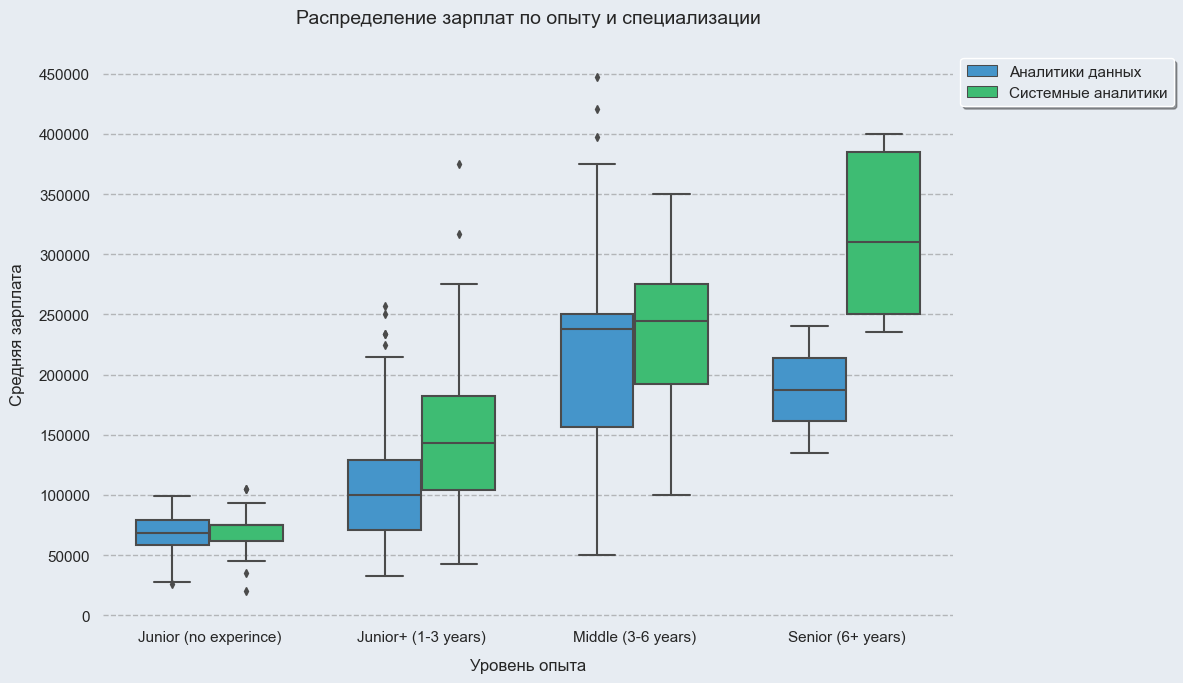

In [29]:
# Настройка стиля
sns.set(rc={'axes.facecolor':'#e7ecf2', 'figure.facecolor':'#e7ecf2'}, 
        font_scale=1)
plt.figure(figsize=(12, 7))
# Создаем boxplot с кастомной палитрой
ax = sns.boxplot(data=conc_df, 
                x='experience', 
                y='avg_salary', 
                hue='type',
                palette=["#3498db","#2ecc71"],  # Синяя и Зелёная
                linewidth=1.5,            
                width=0.7,                 
                fliersize=4,               # Размер выбросов
                saturation=0.8)            

# Настройка оформления
plt.title('Распределение зарплат по опыту и специализации', pad=20, fontsize=14)
plt.xlabel('Уровень опыта', fontsize=12, labelpad=10)
plt.ylabel('Средняя зарплата', fontsize=12, labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Улучшаем легенду
legend = ax.legend(
                   frameon=True, 
                   shadow=True,
                   edgecolor='white',
                   title_fontsize=12,
                   fontsize=11,
                   bbox_to_anchor=(1, 1), 
                   loc='upper left')

# Добавляем сетку только по оси Y
ax.yaxis.grid(True, linestyle='--', color='gray', alpha=0.5)
ax.xaxis.grid(False)

# Убираем лишние линии рамки
sns.despine(left=True, bottom=True)
plt.yticks(np.arange(0, 500000, 50000))
plt.tight_layout()
plt.show()

Есть чёткая тенденция: на всех уровнях позиций (Junior+, Middle, Senior) системные аналитики показывают более высокие медианные зарплаты по сравнению с аналитиками данных. Менее всего она заметна на уровнях Junior и Middle.
Для обеих специализаций наблюдается двухкратный рост  зп. при переходе между грейдами. В выборке Senior системные аналитики показывают несколько более низкие зарплаты по сравнению с Middle-уровнем, что объясняется недостаточным размером выборок (менее 10 наблюдений), и требует дополнительной проверки на более репрезентативных данных.

**Аналитики данных**

In [30]:
(pd.DataFrame(da.experience.value_counts())
    .reset_index()
    .rename(columns={'index': 'Grade', 'experience': 'count'})
    .style.background_gradient(cmap='Blues', subset=['count']))


,Grade,count
0,Junior+ (1-3 years),1091
1,Middle (3-6 years),555
2,Junior (no experince),141
3,Senior (6+ years),13


**Системные аналитки**

In [31]:
(pd.DataFrame(sa.experience.value_counts())
    .reset_index()
    .rename(columns={'index': 'Grade', 'experience': 'count'})
    .style.background_gradient(cmap='Greens', subset=['count']))

,Grade,count
0,Middle (3-6 years),933
1,Junior+ (1-3 years),852
2,Junior (no experince),86
3,Senior (6+ years),43


**Общий вывод:**
- Работодатели более лояльны к аналитикам данных без опыта и предлагают больше рабочих мест .
- У дата-аналитиков больше вакансий для начинающих как без опыта, так и на уровне Junior+.
- На уровне middle-позиций (опыт 3-6 лет) отмечается значительный перевес в пользу системных аналитиков - их доля составляет около 50% от общего числа вакансий, что примерно вдвое превышает количество предложений для аналитиков данных с аналогичным опытом.

<a id='part' a>

### 2.3 Доли ваканский по грейдам

<span style="color:#4994c6">**Аналитики данных**</span>

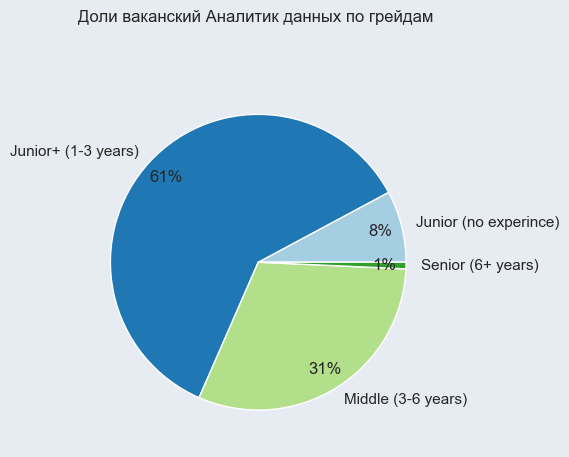

In [32]:
sns.set(rc={'axes.facecolor':'#e7ecf2', 'figure.facecolor':'#e7ecf2'}, 
        font_scale=1)
grade_pie = da.groupby('experience')['id'].count()
palette_color = sns.color_palette('Paired')
plt.pie(grade_pie.values,
        labels=grade_pie.index,
        colors=palette_color,
        pctdistance=.85,
        autopct='%.0f%%')
plt.title("Доли ваканский Аналитик данных по грейдам ", fontsize=12, pad=40)
plt.show();

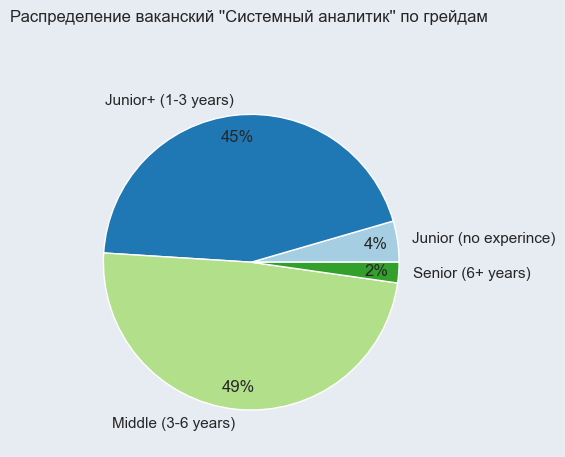

In [33]:
grade_pie = sa.groupby('experience')['id'].count()
palette_color = sns.color_palette('Paired')
plt.pie(grade_pie.values,
        labels=grade_pie.index,
        colors=palette_color,pctdistance=.85,
        autopct='%.0f%%')
plt.title("Распределение ваканский ''Системный аналитик'' по грейдам ",
          fontsize=12,
          pad=40)
plt.show();

Большинство работодателей рассматривают кандидатов на позиции аналитиков с опытом от одного до шести лет. При этом только 8% организаций готовы рассмотреть соискателей без опыта на позиции Junior в направлении "Аналитик данных", и всего 4% — для системных аналитиков.

Более 60% вакансий в категории "Аналитик данных" ориентированы на кандидатов с опытом работы от одного до трёх лет. В свою очередь, среди вакансий для системных аналитиков наибольшую долю составляют предложения, требующие более опытных специалистов — со стажем от трёх до шести лет.

Количество вакансий уровня Junior+ для аналитиков данных превышает аналогичный показатель для системных аналитиков на 15%.

Ситуация с Senior-позициями выглядит сложнее: в датасете по направлению "Аналитик данных" представлено всего 13 вакансий с указанием грейда Senior. Несмотря на то, что грейд обычно коррелирует с опытом, эта связь не всегда однозначна. Для точной оценки уровня стоит обращать внимание на перечень требуемых навыков, должностные обязанности, уровень ответственности и размер заработной платы.

**Выводы**
- Легче всего войти в аналитику через Junior+ (1+ год опыта).
- Системные аналитики требуют больше опыта — если цель войти в IT быстрее, data-аналитика приоритетнее.
- Senior-позиции встречаются редко, однако уровень зарплат на Middle-позициях зачастую сопоставим с Senior-уровнем. Ключевым фактором здесь будет используемый стек технологий.

## 2.4 Топ работодатели
#### <span style="color:#4994c6">**Аналитики данных**</span>

In [34]:
# Немного изменим название некоторых компаний для красоты визуализации.
da.loc[da.employer == 'МАГНИТ, Розничная сеть', 'employer'] = 'МАГНИТ'
da.loc[da.employer == 'Центральный банк Российской Федерации', 'employer'] = 'ЦБ РФ'
sa.loc[sa.employer == 'Центральный банк Российской Федерации', 'employer'] = 'ЦБ РФ'
da.loc[da.employer == 'ГКУ Центр занятости населения города Москвы', 'employer'] = 'Центр занятости г. Москвы'

<a id='top_da' a>

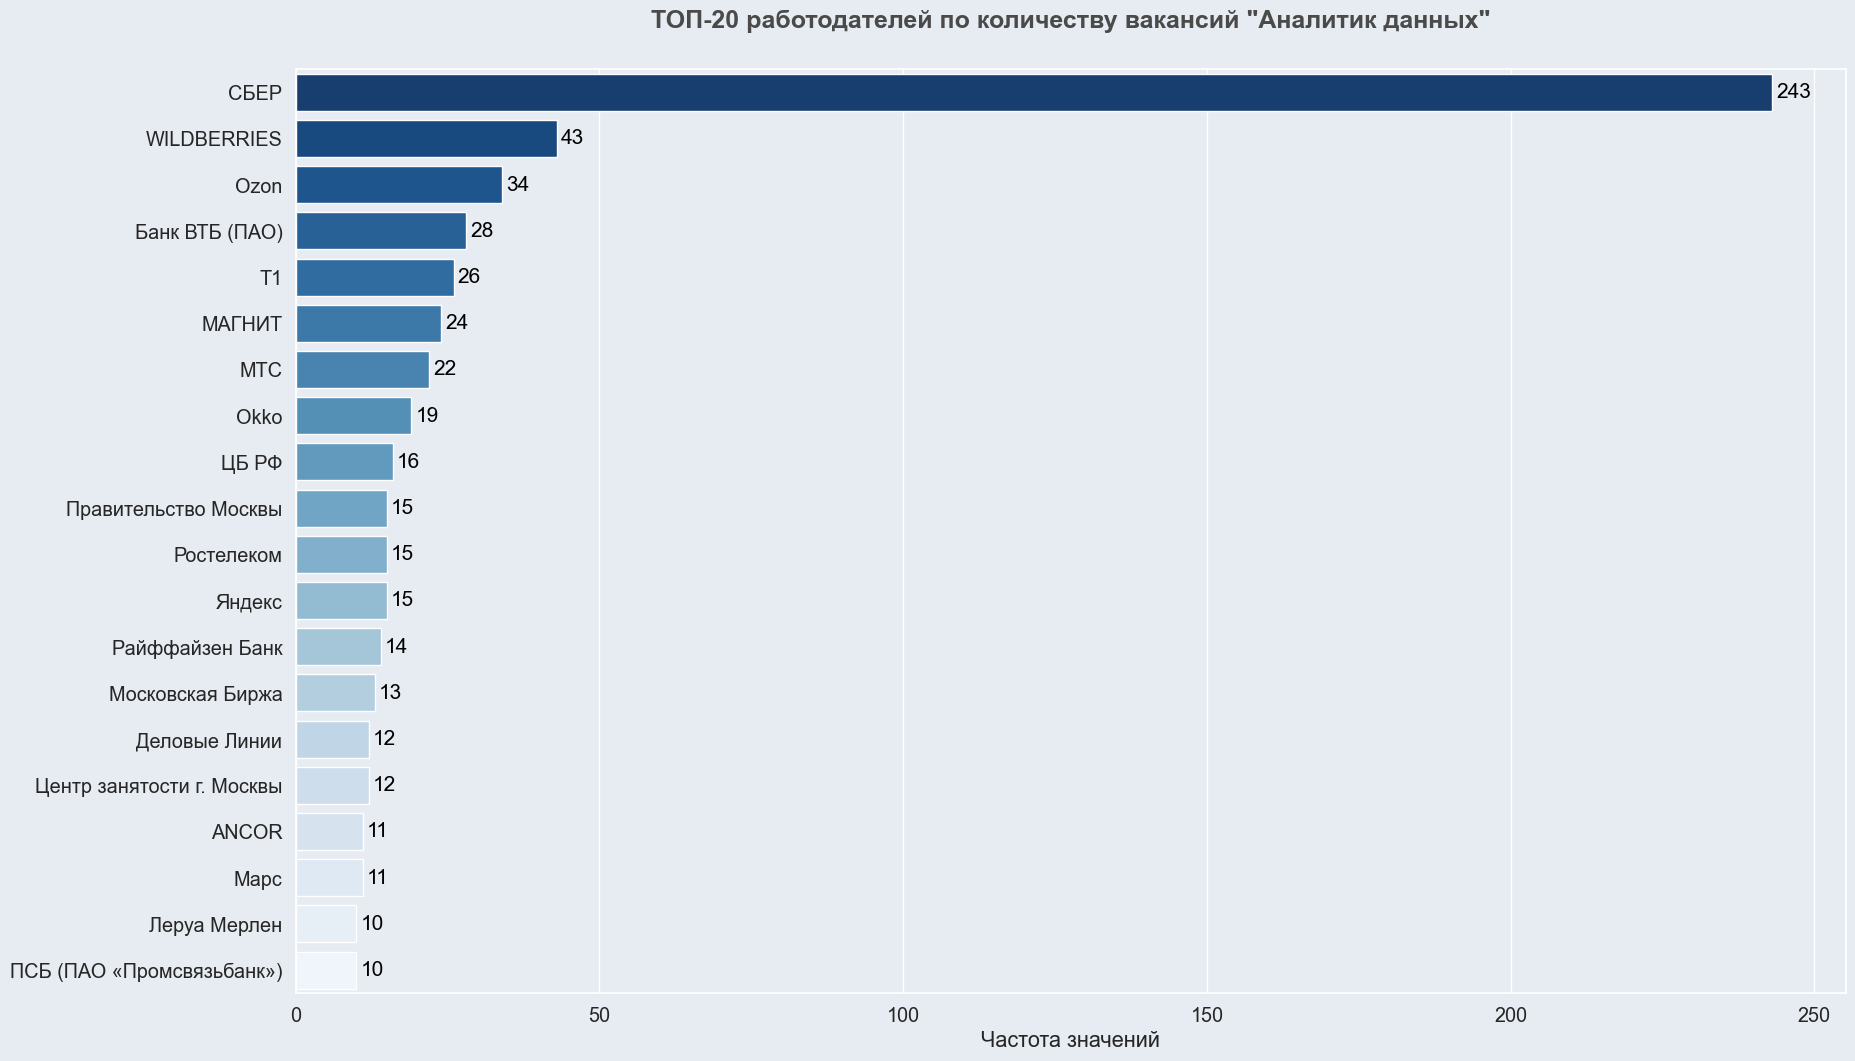

In [35]:
# Настройка стиля и размера
sns.set(rc={'axes.facecolor':'#e7ecf2', 'figure.facecolor':'#e7ecf2'},font_scale= 1.3)

plt.figure(figsize=(20, 12))


# Построение графика
ax = sns.barplot(da.groupby('employer')
                 .id.count()
                 .nlargest(20)
                 .reset_index(),
                 x='id',
                 y='employer',
                 palette='Blues_r')

ax.set_title('ТОП-20 работодателей по количеству вакансий "Аналитик данных"', 
             size=18, pad=30, weight='bold', color='#4a4a4a')

# Настройка заголовка и подписей

ax.set_ylabel('')
ax.set_xlabel('Частота значений')
# Значение на барах
for i in ax.containers:
    ax.bar_label(
        i,
        label_type='edge',  # Значения снаружи столбца
        padding=3,          # Отступ от края
        fontsize=15,
        color='black',    # Цвет текста
    )

    
ax;

С большим отрывом лидирует  эко-система СБЕР с предложением 243 вакансиий.Далее расположились крупные онлайн гипермаркеты . В целом все сегменты рынка имеют широкий спектр вакансий для аналитиков данных. 

Основные это:
- Финансовый сектор (крупные банки и финтех-компании)
- ИТ-интеграторы (системные внедренческие компании)
- Медиахолдинги (платформы с большими объемами контент-данных)
- Ритейл и e-commerce (онлайн-гипермаркеты, маркетплейсы)

<a id='top_sa' a>

In [36]:
sa.loc[sa.employer == 'Совкомбанк Технологии', 'employer'] = 'Совкомбанк Тех.'
sa.loc[sa.employer == 'Красное & Белое, розничная сеть', 'employer'] = 'К&Б розн. сеть'
sa.loc[sa.employer == 'Ростелеком Информационные Технологии', 'employer'] = 'Ростелеком ИТ'
sa.loc[sa.employer == 'БФТ-Холдинг (Бюджетные и Финансовые Технологии)', 'employer'] = 'БФТ-Холдинг'

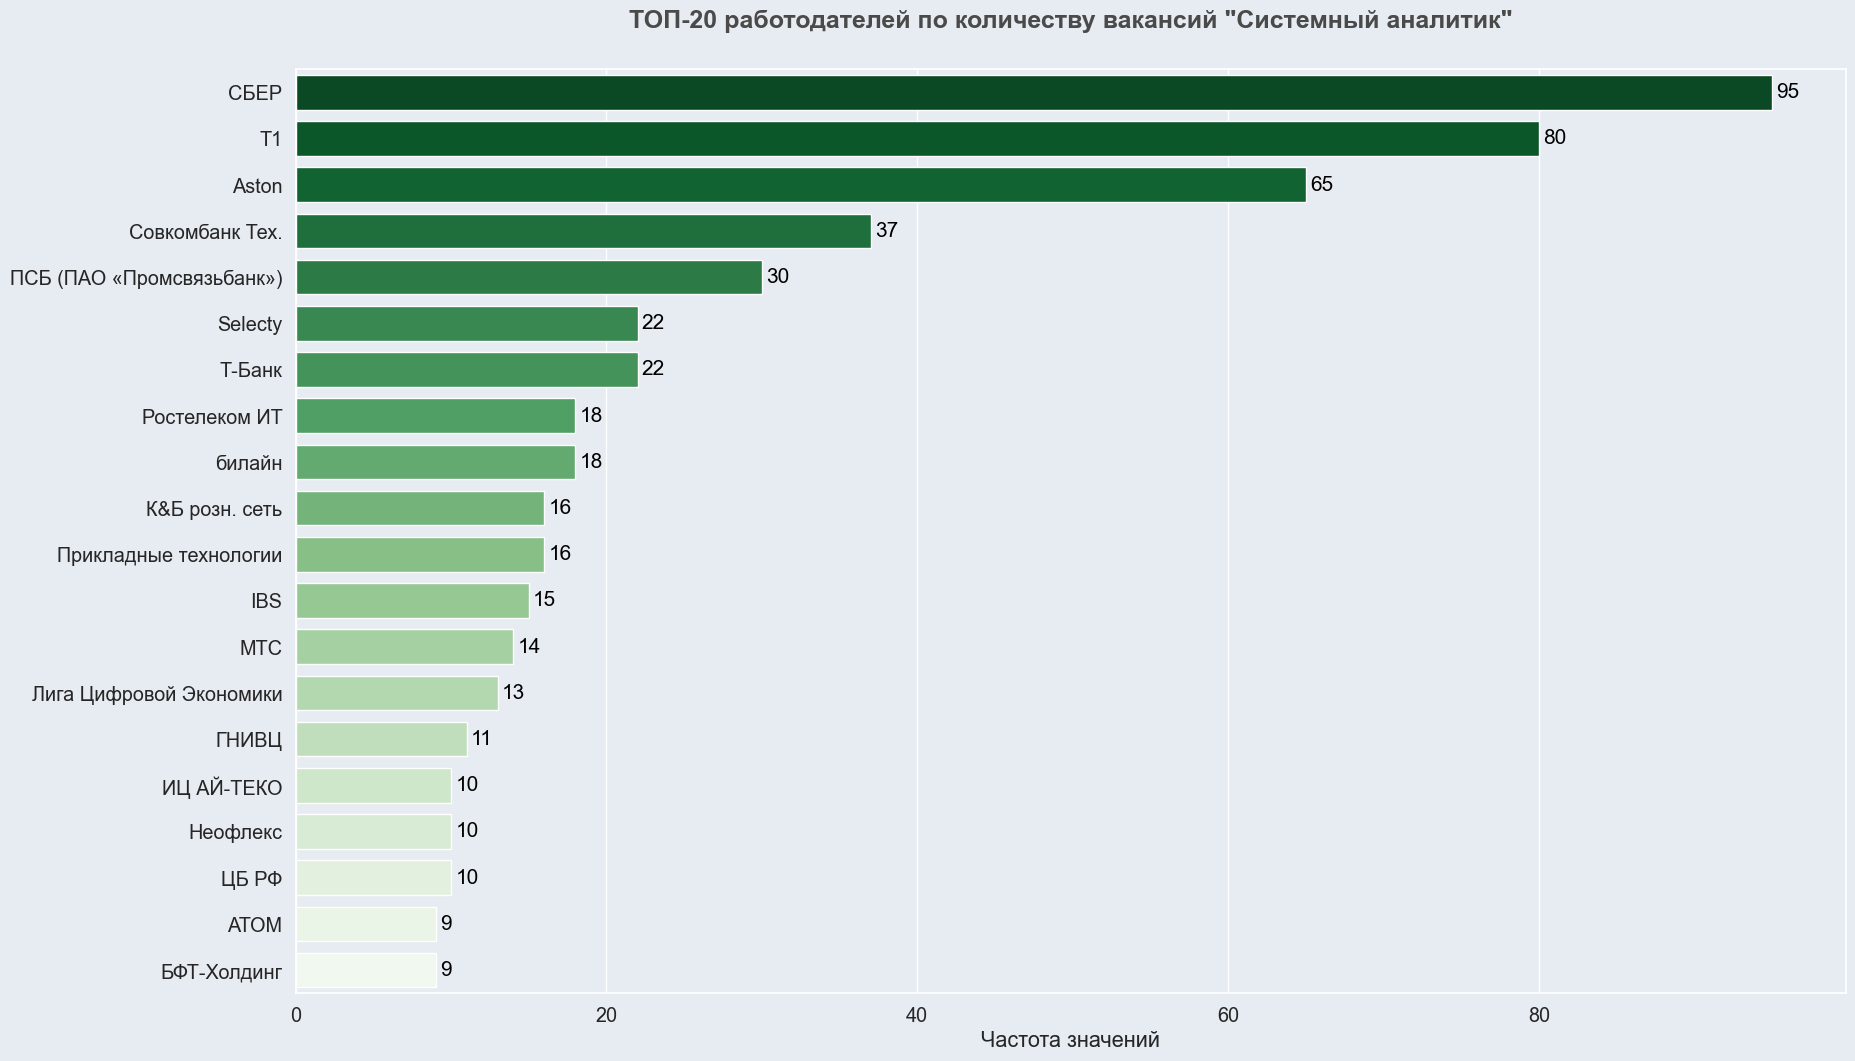

In [37]:
# Настройка стиля и размера
sns.set(rc={'axes.facecolor':'#e7ecf2', 'figure.facecolor':'#e7ecf2'},font_scale= 1.3)

plt.figure(figsize=(20, 12))


# Построение графика
ax = sns.barplot(sa.groupby('employer')
                 .id.count()
                 .nlargest(20)
                 .reset_index(),
                 x='id',
                 y='employer',
                 palette='Greens_r',
                 width=.75)

ax.set_title('ТОП-20 работодателей по количеству вакансий "Системный аналитик"', 
             size=18, pad=30, weight='bold', color='#4a4a4a')

# Настройка заголовка и подписей

ax.set_ylabel('')
ax.set_xlabel('Частота значений')
# Значение на барах
for i in ax.containers:
    ax.bar_label(
        i,
        label_type='edge',  
        padding=3,          
        fontsize=15,
        color='black',    
    )

    
ax;


Среди работодателей, предлагающих вакансии системных аналитиков, нет единоличного лидера. Основной спрос на системных аналитиков сосредоточен:
- Финансовый сектор
- ИТ-консалтинг 
- Телекоммуникациях.

<a id='top_grade' a>

### 2.5 Топ работодатели по грейдам
#### <span style="color:#4994c6">**Аналитики данных**</span>

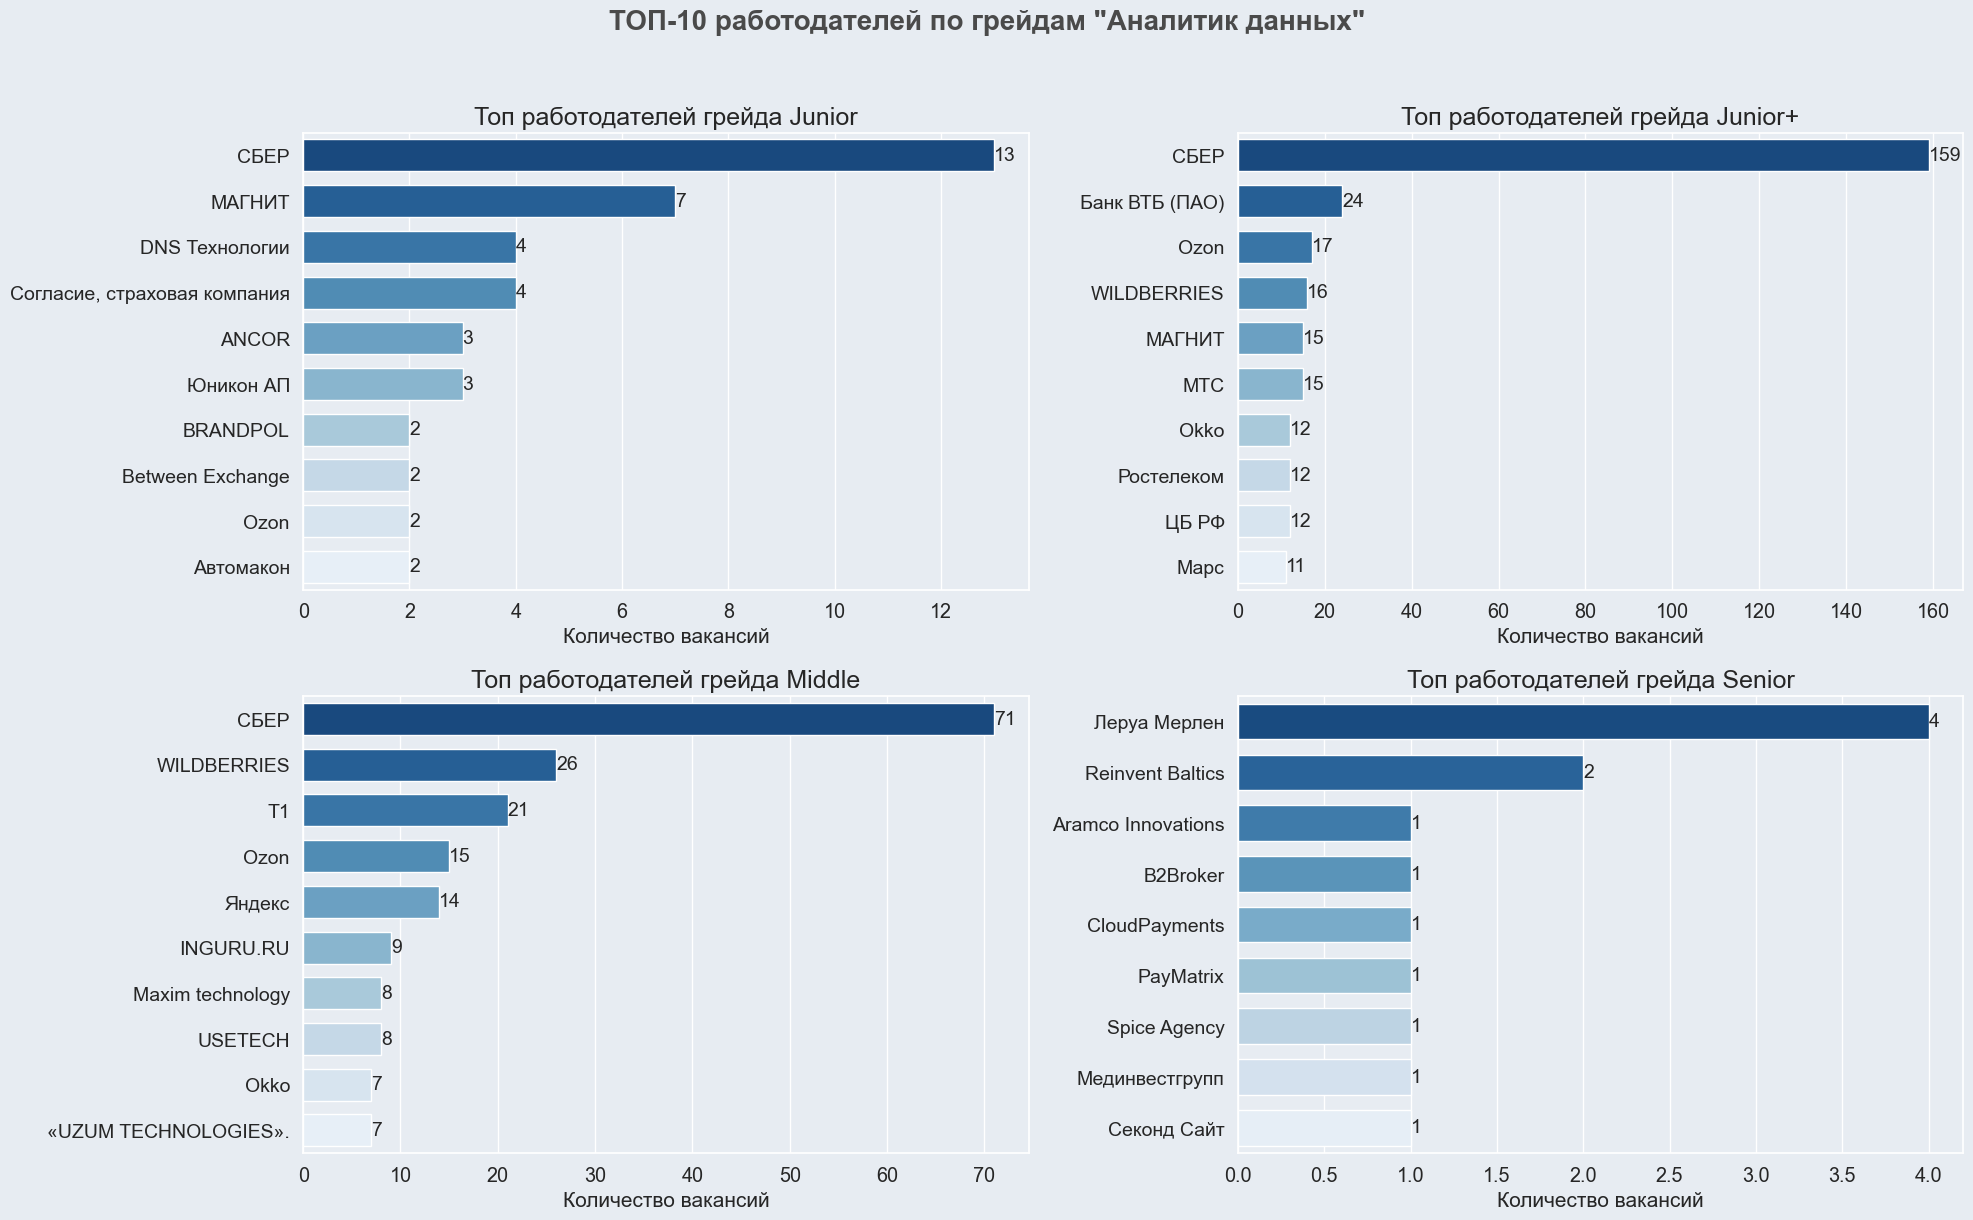

In [38]:
# Настройка стиля и создание фигуры
sns.set(rc={'axes.facecolor':'#e7ecf2', 'figure.facecolor':'#e7ecf2'}, font_scale=1.3)
figure, axes = plt.subplots(2, 2, figsize=(20, 12))

# название графика
plt.suptitle('ТОП-10 работодателей по грейдам "Аналитик данных"', 
                size=20, y=1.02, weight='bold', color='#4a4a4a')

# Конфигурация 
config = [
    {'exp': "Junior (no experince)", 'title': "Junior", 'pos': (0,0)},
    {'exp': "Junior+ (1-3 years)", 'title': "Junior+", 'pos': (0,1)},
    {'exp': "Middle (3-6 years)", 'title': "Middle", 'pos': (1,0)},
    {'exp': "Senior (6+ years)", 'title': "Senior", 'pos': (1,1)}
]



# Построение графиков
for cfg in config:
    ax = axes[cfg['pos']]
    df = (da.query(f'experience == "{cfg["exp"]}"')
            .groupby('employer')
            .id.count()
            .nlargest(10)
            .reset_index())
    
    sns.barplot(data=df, x='id', y='employer', 
                palette='Blues_r', ax=ax, width=0.7)
    
    ax.set_title(f'Топ работодателей грейда {cfg["title"]}', size=18)
    ax.set_xlabel('Количество вакансий', size=15)
    ax.set_ylabel('')
    ax.yaxis.set_tick_params(labelsize=14)
    
    for container in ax.containers:
        ax.bar_label(container, label_type='edge', size=14)

      
        
        

plt.tight_layout()

- Главным работодателей для data-аналитиков всех грейдов, за исключением Senior,  всё тот же   СБЕР. Также в топе крупные ритейлеры и онлайн-гипермаркеты: Wildberries, Магнит, Ozon. Стоит отметить, что компания Леруа Мерлен на высокие позиции указывает именно 6+ летний опыт работы в этой сфере.

<a id='top_grade_sa' a>


### Системные аналитки

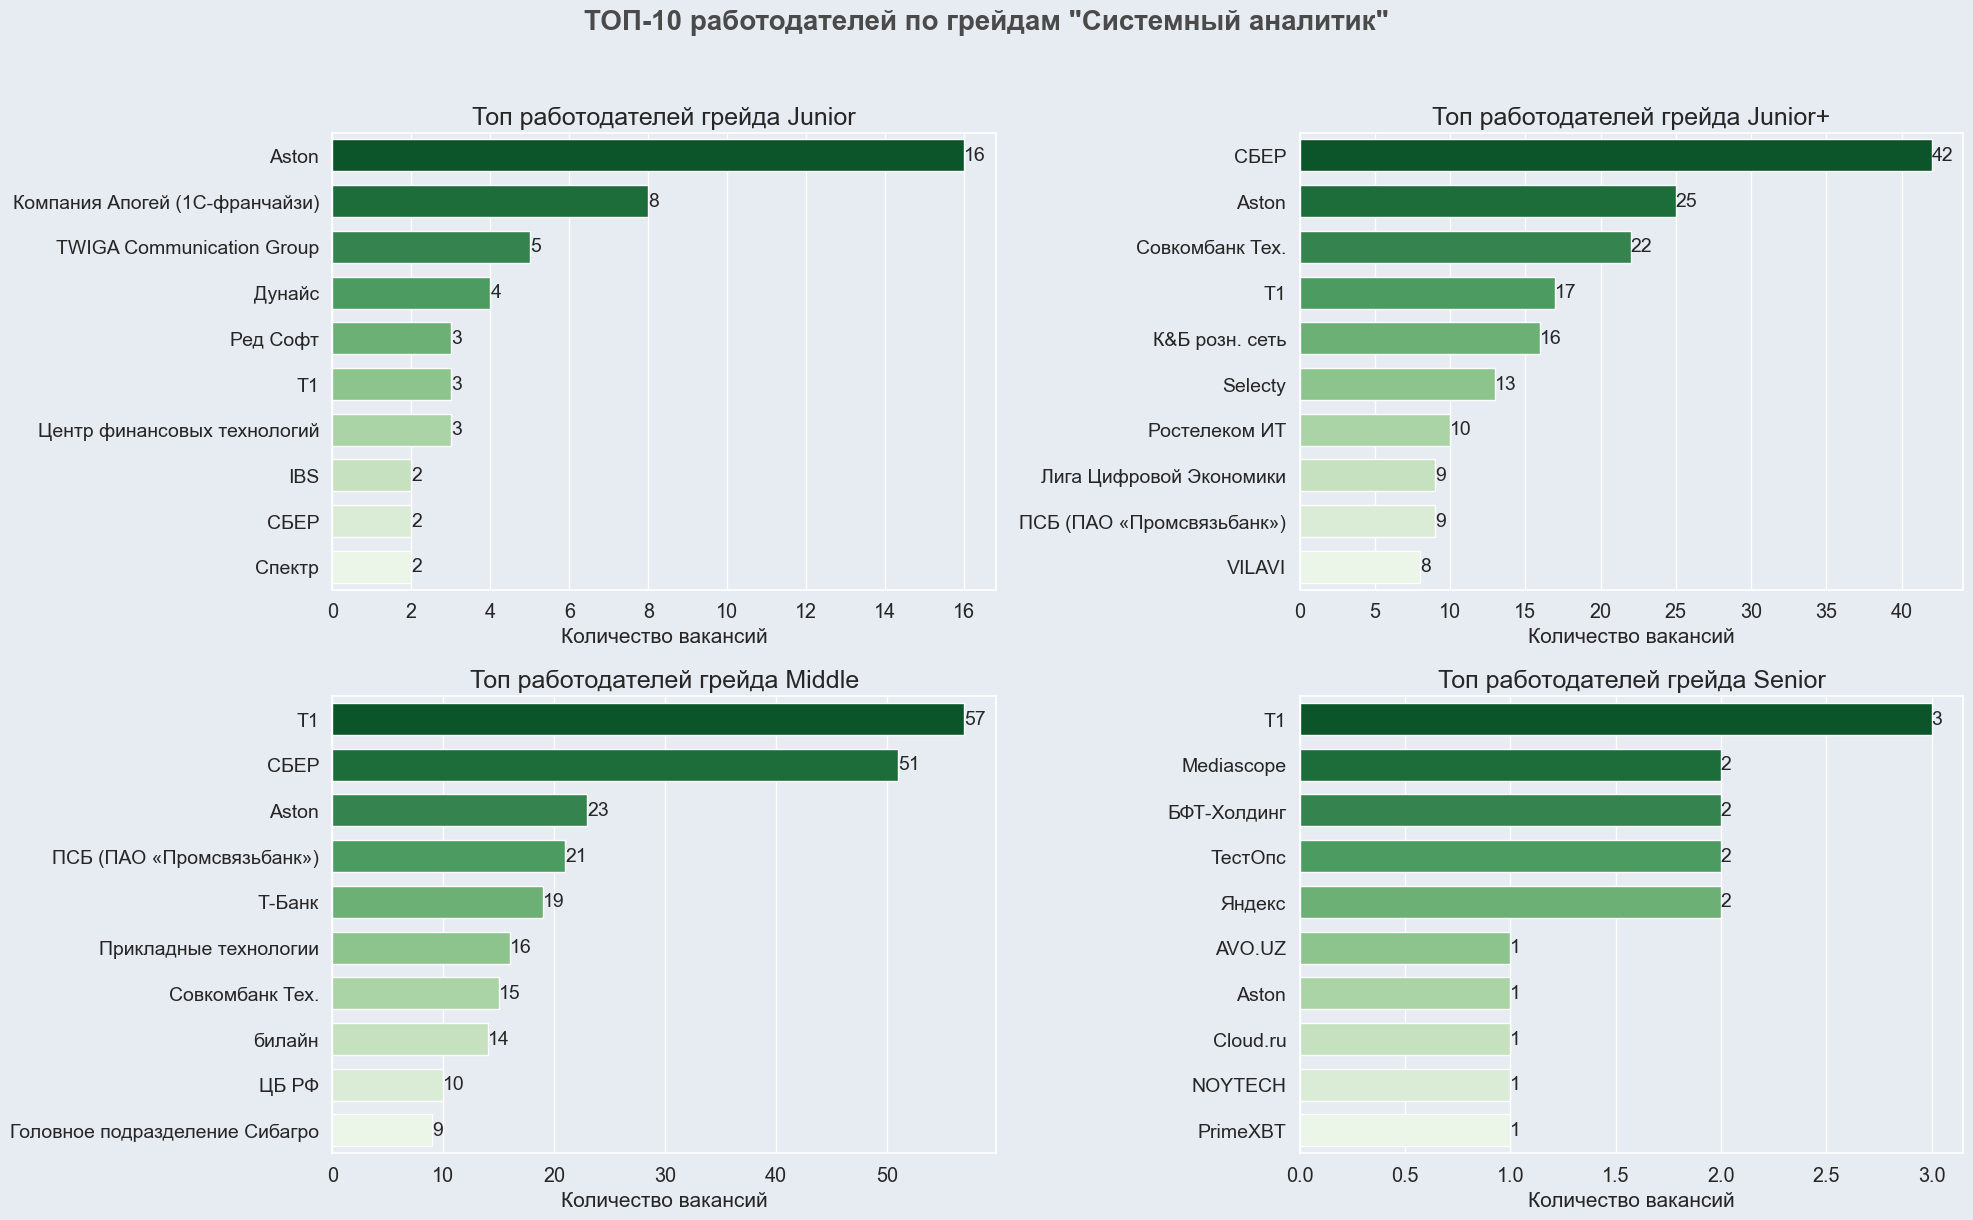

In [39]:
# Настройка стиля и создание фигуры
sns.set(rc={'axes.facecolor':'#e7ecf2', 'figure.facecolor':'#e7ecf2'}, font_scale=1.3)
figure, axes = plt.subplots(2, 2, figsize=(20, 12))

# название графика
plt.suptitle('ТОП-10 работодателей по грейдам "Системный аналитик"', 
                size=20, y=1.02, weight='bold', color='#4a4a4a')

# Конфигурация 
config = [
    {'exp': "Junior (no experince)", 'title': "Junior", 'pos': (0,0)},
    {'exp': "Junior+ (1-3 years)", 'title': "Junior+", 'pos': (0,1)},
    {'exp': "Middle (3-6 years)", 'title': "Middle", 'pos': (1,0)},
    {'exp': "Senior (6+ years)", 'title': "Senior", 'pos': (1,1)}
]



# Построение графиков
for cfg in config:
    ax = axes[cfg['pos']]
    df = (sa.query(f'experience == "{cfg["exp"]}"')
            .groupby('employer')
            .id.count()
            .nlargest(10)
            .reset_index())
    
    sns.barplot(data=df, x='id', y='employer', 
                palette='Greens_r', ax=ax, width=0.7)
    
    ax.set_title(f'Топ работодателей грейда {cfg["title"]}', size=18)
    ax.set_xlabel('Количество вакансий', size=15)
    ax.set_ylabel('')
    ax.yaxis.set_tick_params(labelsize=14)
    
    for container in ax.containers:
        ax.bar_label(container, label_type='edge', size=14)

      
        
        

plt.tight_layout()

- Похожая ситуация и у системных аналитиков. Лидерами по предлагаемым вакансиям остаются банки и компании с развитыми экосистемами. Стоит отметить отсутсвие онлайн гипермаркетов. Их заменили крупные ИТ-интегратор Т1 и компания по разработке  ПО - Aston. СБЕР  с двумя вакансиями не заинтересован в джунах без опыта .

**Выводы и рекомендации для соискателей:**

**Для аналитиков данных:**

Junior/Junior+ (0-3 года опыта):
- Фокус на СБЕР и крупный ритейл (Wildberries, Ozon, Магнит) – эти компании предлагают больше всего вакансий для начинающих.

Middle (3-6 лет опыта):
- Широкий выбор работодателей (банки, ритейл, ИТ-компании).

Senior (6+ лет):
- Узкий рынок: Леруа Мерлен и другие компании ищут экспертов с глубоким опытом.

**Для системных аналитиков:**

Начинающим (Junior):
- СБЕР почти не берет новичков – ищите вакансии в ИТ-интеграторах (T1, Aston).

Middle/Senior (3+ лет):

- Банки и телеком – основные работодатели.


<a id='format_da' a>

### 2.6 Доли предлагаемых вакансий  по графику работы.


**Аналитики данных**

In [40]:
pivot_df = pd.pivot_table(
    da,
    index='experience',
    columns='schedule', 
    values='id',
    aggfunc='count',
    fill_value=0
)

# Форматируем таблицу
styled_table = (pivot_df
                .style
                .background_gradient(cmap='Blues', axis=1, vmin=0,vmax=450)
                .set_properties(**{
                    'text-align': 'center',
                    'font-size': '12px',
                    'border': '1px blue'
                }))


styled_table

schedule,Гибкий график,Полный день,Сменный график,Удаленная работа
experience,,,,
Junior (no experince),3,122,2,14
Junior+ (1-3 years),21,905,7,158
Middle (3-6 years),17,406,0,132
Senior (6+ years),0,8,0,5


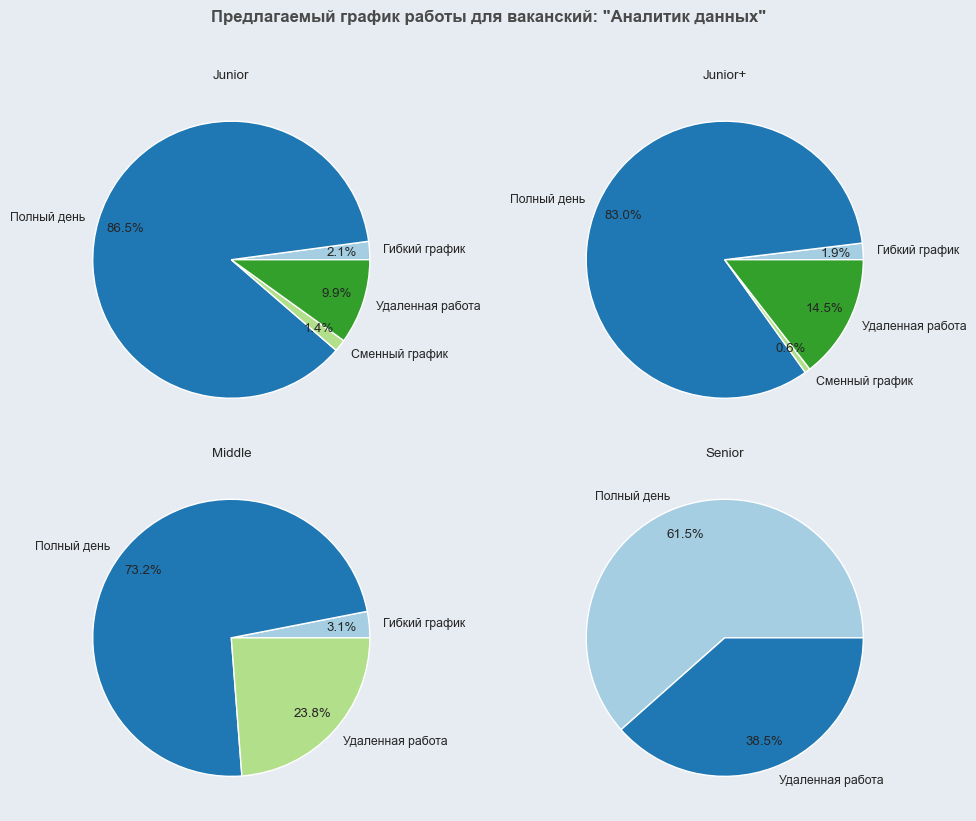

In [41]:
palette_color = sns.color_palette('Paired')
sns.set(rc={'axes.facecolor':'#e7ecf2', 'figure.facecolor':'#e7ecf2'}, 
        font_scale=0.8)
# Создаем подграфики
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

plt.suptitle('Предлагаемый график работы для ваканский: "Аналитик данных"', 
                size=12, y=1.02, weight='bold', color='#4a4a4a')

# Список условий для выборок
experience_levels = [
    ("Junior (no experince)", 'Junior'),
    ("Junior+ (1-3 years)", 'Junior+'),
    ("Middle (3-6 years)", 'Middle'), 
    ("Senior (6+ years)", 'Senior')
]

# Строим круговые диаграммы
for (exp, title), ax in zip(experience_levels, axes.flat):
    df = da.query(f'experience == "{exp}"').groupby('schedule').size()
    ax.pie(df, labels=df.index, autopct='%1.1f%%', colors=palette_color, pctdistance=.8)
    ax.set_title(title)

plt.tight_layout()
plt.show()

**Аналитики данных**

**Junior/Junior+ аналитики:**
Около 85% вакансий  для data-аналитиков  начальных грейдов предполагают офисный формат работы. Это можно объяснить тем, что на входном уровне важнее процесс обучения и интеграции в команду, чем непосредственные результаты.

**Middle-аналитики:**
Работодатели становятся более гибкими - около 25% вакансий допускают удалённый формат. Это связано с тем, что специалисты среднего уровня уже обладают достаточным опытом для самостоятельной работы и требовательны к условиям личного комфорта или возможности релокации.

**Senior-аналитики:**
Более 35% вакансий предлагают удалённую работу, так как высококвалифицированные специалисты демонстрируют устойчивые результаты независимо от места работы.

Стоит отметить, что приведённые данные носят оценочный характер из-за ограниченного размера выборки. Тенденция, однако, прослеживается достаточно чётко: чем выше квалификация специалиста, тем больше работодателей готовы предлагать гибкие условия работы.

<a id='format_sa' a>

#### Для системных аналитиков

In [42]:
pivot_df = pd.pivot_table(
    sa,
    index='experience',
    columns='schedule', 
    values='id',
    aggfunc='count',
    fill_value=0
)

# Форматируем таблицу
styled_table = (pivot_df
                .style
                .background_gradient(cmap='Greens', axis=1, vmin=0,vmax=450)
                .set_properties(**{
                    'text-align': 'center',
                    'font-size': '12px',
                    'border': '1px solid white'
                }))


styled_table

schedule,Гибкий график,Полный день,Сменный график,Удаленная работа
experience,,,,
Junior (no experince),6,51,0,29
Junior+ (1-3 years),36,553,0,263
Middle (3-6 years),17,574,1,341
Senior (6+ years),2,25,0,16


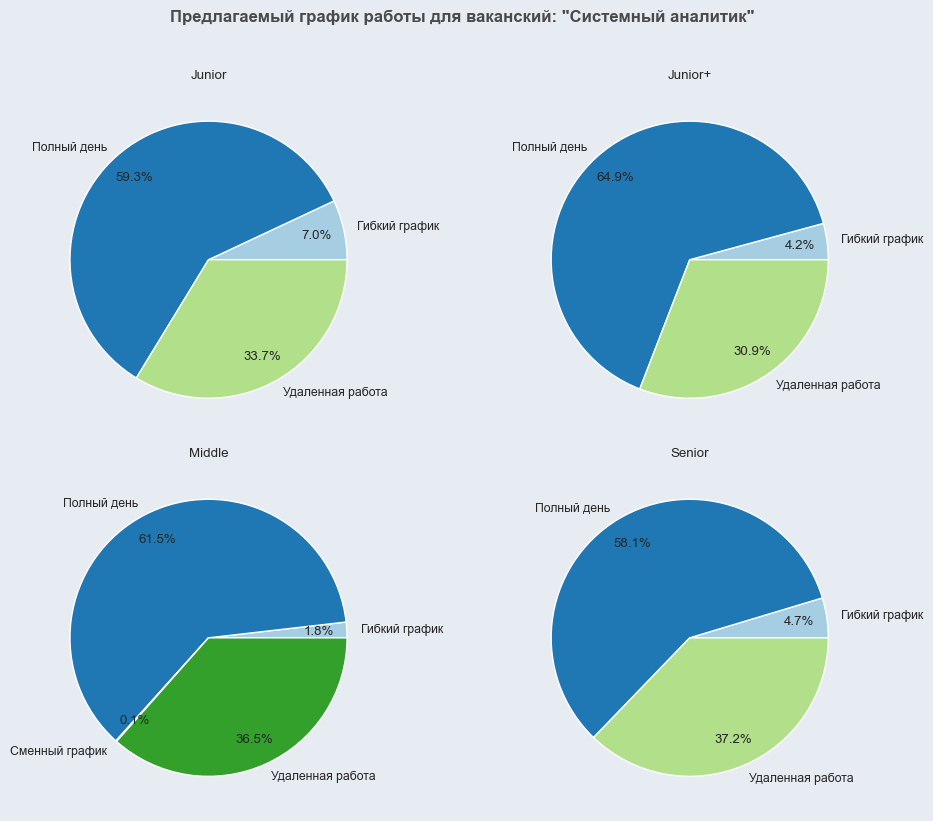

In [43]:
palette_color = sns.color_palette('Paired')
sns.set(rc={'axes.facecolor':'#e7ecf2', 'figure.facecolor':'#e7ecf2'}, 
        font_scale=0.8)
# Создаем подграфики
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

plt.suptitle('Предлагаемый график работы для ваканский: "Системный аналитик"', 
                size=12, y=1.02, weight='bold', color='#4a4a4a')

# Список условий для выборок
experience_levels = [
    ("Junior (no experince)", 'Junior'),
    ("Junior+ (1-3 years)", 'Junior+'),
    ("Middle (3-6 years)", 'Middle'), 
    ("Senior (6+ years)", 'Senior')
]

# Строим круговые диаграммы
for (exp, title), ax in zip(experience_levels, axes.flat):
    df = sa.query(f'experience == "{exp}"').groupby('schedule').size()
    ax.pie(df, labels=df.index, autopct='%1.1f%%', colors=palette_color,pctdistance=.8)
    ax.set_title(title)

plt.tight_layout()
plt.show()

**Junior/junior+**

- Уже на стадии взодного уровня ~32% вакансий для Junior/Junior+ предлагают удалённую работу. Этот результат несравнимо выше по сравнению с data-аналитиками.При этом у новичков без опыта этот процент ещё выше, что , скорее всего, обусловлено либо ограниченной выборкой, либо акцентом на привлечение молодых специалистов последних курсов учебных заведений. Отноительно высокий процент ваканский с гибким графиком только подтверждает последнюю гипотезу.


**Middle/Senior:**

- Ваканский с работой в офисе становится чуть меньше по сравнению с Junior+ позициями, а проценты с гибким графиком "перетекают" в удалёнку. Тем не менее , в относительных цифрах, разница не так выразительна, и доли стабильны на всех грейдах.


<a id='type' a>

## 2.7 Тип занятости.


In [44]:
da_pivot = da.pivot_table(index='employment', columns='experience', 
                         values='id', aggfunc='count').fillna(0).astype(int)

sa_pivot = sa.pivot_table(index='employment', columns='experience', 
                         values='id', aggfunc='count').fillna(0).astype(int)

# Функция для стилизации с градиентом
def style_pivot(df,cmap):
    return (df.style
            .background_gradient(cmap=cmap, axis=None)
            .set_properties(**{'text-align': 'center'}))

# Отображаем результаты
from IPython.display import display, Markdown

display(Markdown("**Аналитики данных (количество вакансий)**"))
display(style_pivot(da_pivot,'Blues'))

display(Markdown("**Системные аналитики (количество вакансий)**"))
display(style_pivot(sa_pivot,'Greens'))


**Аналитики данных (количество вакансий)**

experience,Junior (no experince),Junior+ (1-3 years),Middle (3-6 years),Senior (6+ years)
employment,,,,
Полная занятость,122,1079,549,13
Проектная работа,1,3,1,0
Стажировка,15,1,0,0
Частичная занятость,3,8,5,0


**Системные аналитики (количество вакансий)**

experience,Junior (no experince),Junior+ (1-3 years),Middle (3-6 years),Senior (6+ years)
employment,,,,
Полная занятость,56,851,926,43
Проектная работа,0,1,2,0
Стажировка,29,0,0,0
Частичная занятость,1,0,5,0


**Выводы**
- Полная занятость — основной формат для обеих профессий .
- Стажировки доступны только Junior, но у системных аналитиков их почти в 2 раза больше (29 vs. 15).
- Гибкие форматы (проектная/частичная занятость) почти не развиты.

**Рекомендации**

Junior: ориентироваться на полную занятость или стажировки (особенно в системном анализе).
Middle/Senior: Почти во всех случаях - полная занятость.

<a id='skills' a>

## 2.8 Ключевые навыки 

In [45]:
@dataclass
class Palette:
    dark: str
    light: str
    lighter: str
    text: str
        
# Маппинг навыков 
skill_mapping = {
        # Нормализация регистра и вариантов SQL
        'Ms Sql': 'SQL', 
        'Sql': 'SQL',
        'sql': 'SQL',
        'ms sql': 'SQL',
        'postgresql': 'SQL',
        'mysql': 'SQL',
        'oracle sql': 'SQL',
        'pl/sql': 'SQL',
        't-sql': 'SQL',
        'субд': 'SQL',
        'работа с базами данных':'базы данных',
        'Работа С Большим Объемом Информации': 'big data',
        'работа с большим объемом информации': 'big data',
        
        # Нормализация BI-инструментов
        'power bi' : 'Power BI',
        'powerbi': 'Power BI',
        'ms power bi': 'Power BI',
        'powerbi desktop': 'Power BI',
        'tableau': 'Tableau',
        'qlik': 'Qlik Sense',
        'qlik sense': 'Qlik Sense',
        'datalens': 'DataLens',
    
        # Статистика
    
        'статистика' : 'статистический анализ',
        'математическая статистика': 'статистический анализ',
        'Математическая Статистика': 'статистический анализ',
        # Нормализация Python и библиотек
        'python': 'Python',
        'python 3': 'Python',
        'pandas': 'Pandas',
        'numpy': 'NumPy',
        'scikit-learn': 'Scikit-learn',
        
        # Нормализация Excel
        'excel': 'MS Excel',
        'ms excel': 'MS Excel',
        'microsoft excel': 'MS Excel',
        'advanced excel': 'MS Excel',
        
        # Нормализация 1С
        '1с': '1С',
        '1с предприятие': '1С',
        '1с:предприятие': '1С',
        '1с 8': '1С',
        '1с программирование': '1С',
        
        # Нормализация анализа данных
        'data analysis': 'Анализ данных',
        'анализ данных': 'Анализ данных',
        'data analytics': 'Аналитика данных',
        'data science': 'Data Science',
        'big data': 'Big Data',
        'машинное обучение': 'Machine Learning',
        'ml': 'Machine Learning',
        
        # Нормализация других технологий
        'api': 'API',
        'rest api': 'API',
        'json': 'JSON',
        'xml': 'XML',
        'git': 'Git',
        'docker': 'Docker',
        'linux': 'Linux',
        
        # Нормализация soft skills
        'аналитическое мышление': 'аналитическое мышление',
        'analytical thinking': 'аналитическое мышление',
        'английский язык': 'английский язык',
        'english': 'aнглийский язык',
        'работа в команде': 'работа в команде',
        'teamwork': 'работа в команде'
    }



blues = Palette('#1f77b4', '#a6c6e3', '#d0e0f0', '#ffffff')
greens = Palette('#2ca02c', '#a6dba6', '#d0efd0', '#ffffff')

# Обработка навыков 
def process_skills(df, mapping=skill_mapping, skill_col='key_skills_from_key_skills_field'):
    return (
        df[df[skill_col].notna()][skill_col]
        .str.lower()
        .str.split(',')
        .explode()
        .str.strip()
        .replace(mapping)
        .value_counts()
        .head(100)
        .reset_index()
        .rename(columns={'index': 'Навык', skill_col: 'Частота'})
    )

# Стилизация таблицы
def get_table_styles(color_palette):
    return [
        {'selector': 'thead th',
         'props': [('background-color', color_palette.dark), ('color', color_palette.text), ('font-weight', 'bold')]},
        {'selector': 'tbody tr:nth-child(odd)', 'props': [('background-color', color_palette.light)]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [('background-color', color_palette.lighter)]},
        {'selector': 'th, td', 'props': [('border', '1px solid #ddd'), ('padding', '8px')]},
        {'selector': 'caption', 'props': [('font-size', '16px'), ('margin-bottom', '10px')]},
    ]

def style_skills(df, title, palette):
    return (
        df.head(30).style
        .set_table_styles(get_table_styles(palette))
        .bar(color=palette.dark, vmin=0)
        .set_caption(f'<b>{title}</b>')
        .set_properties(**{'text-align': 'left', 'width': '400px'})
        .format({'Частота': '{:,}'})
    )

#  Отрисовка HTML 
skills_da = process_skills(da)
skills_sa = process_skills(sa)

table_da = style_skills(skills_da, "Топ-30 навыков Аналитики данных", blues).to_html()
table_sa = style_skills(skills_sa, "Топ-30 навыков Системные аналитики", greens).to_html()

html = f"""
<div style="display: flex; justify-content: space-between; margin-bottom: 20px;">
    <div style="width: 48%; box-shadow: 0 2px 5px rgba(0,0,0,0.1);">{table_da}</div>
    <div style="width: 48%; box-shadow: 0 2px 5px rgba(0,0,0,0.1);">{table_sa}</div>
</div>
"""

display(HTML(html))

,Навык,Частота
0,SQL,"1,006"
1,Python,581
2,Анализ данных,538
3,базы данных,313
4,Power BI,285
5,аналитическое мышление,238
6,MS Excel,230
7,статистический анализ,188
8,big data,183
9,аналитика,175


**Наиболее востребованные навыкы вакансий:**

**Аналитики данных**

---
**Языки программирования и запросов**
- SQL (1006 упоминаний) - фундаментальный навык для любого аналитика. Необходим для извлечения, обработки и анализа данных из реляционных баз.
- Python (581) - Базовый и  библиотеки для анализа данных (Pandas, NumPy) . Используется для сложных расчетов и автоматизации.

**Средства визуализации данных**
- Power BI (в сумме 285) - лидер среди BI-инструментов для отчётов и дашбордов.
- Tableau (94) - как альтернатива Power BI.

**Статистика и аналитические методы**
- Статистический анализ (190) - для выдвижения и математического подтверждения бизнес гипотез.
- Аналитические исследования (99) - умение проектировать и проводить исследования.

**Маркетинговая аналитика**
- A/B тесты (60) - ключевой метод тестирования изменений в продуктах и маркетинге. Требует понимания статистически.
- Анализ бизнес-показателей (62) - работа с KPI, метриками эффективности, построение воронок.

**Дополнительные важные навыки**
- MS Excel (230) - несмотря на развитие BI-инструментов, остается востребованным для быстрого анализа.
- Работа с базами данных (185) - понимание принципов хранения и организации данных. Можно отнести к более углоблённому знанию SQL.
- Аналитическое мышление (238) - способность структурировать задачи и делать обоснованные выводы.

**Вывод по вакансиям data-аналитиков:**

Для аналитика данных клчевыми остаются SQL, Python, Power BI — без них не обходится ни одна вакансия. Python должен усиливать позиции, особенно в компаниях, где нужна сложная обработка данных. 

Статистика и A/B-тесты важны, но упоминаются реже и требуются как дополнение к основным техническим навыкам.


Комбинация инструментов: умение не только добывать данные (SQL), обрабатывать(python),но и визуализировать их (Power BI/Tableau), а также интерпретировать с учётом бизнес-контекста.
Идеальный профиль:
«SQL + BI-инструмент + базовый Python» с пониманием статистики. Остальное — в зависимости от специализации (маркетинг, продукт, финансы).

---
**"Системный аналитик"**


**Работа с данными и базами**
- SQL (907) — Тот же лидер и около тысячи упомянаний в вакансиях. 

**Моделирование процессов и архитектуры**
- BPMN (635) и UML (561) — стандарты для моделирования бизнес-процессов и проектирования архитектуры. Критичны для визуализации требований и взаимодействия с командами.

**Интеграции и API**
- REST (391) и API (269) — обязательные знания для проектирования интеграций и микросервисных архитектур. SOAP (265) и XML (205) сохраняют актуальность в legacy-системах(210).

**Документирование и управление требованиями**

- Техническая документация — разработка ТЗ (245) и постановка задач (210) остаются ядром работы, но требуют гибких форматов (например, OpenAPI, Markdown) 213.

**Бизнес-анализ и мышление**
- Системный анализ (564) 
- Бизнес-анализ (168) 
- Аналитическое мышление (189)

**Инструменты управления** 
- Jira (151) и Confluence (129)

**Вывод по вакансиям SA:**

- SQL + моделирование (BPMN/UML) как техническая база
- Знание современных и legacy технологий интеграции
- Навыки Agile-документирования (Jira+Confluence)
- Глубокое понимание бизнес-процессов
- Способность переводить бизнес-требования в технические решения

<a id='soft' a>

### Разделение на hard и soft навыки

In [46]:
# Самостоятельно разделим навыки на "мякие" 
soft_skills_da =  { 'деловая коммуникация', 'грамотная речь', 'обучение и развитие','анализ рынка',
                   'аналитика',  'аналитика продаж','аналитические способности', 'аналитика', 'аналитический склад ума',
                   'аналитическое мышление',
                   'английский язык', 'бизнес-анализ','грамотная речь', 'деловая коммуникация', 'деловая переписка', 
                   'критическое мышление', 'маркетинговый анализ', 'математический анализ', 'обучение и развитие',
                   'оптимизация бизнес-процессов', 'проведение презентаций', 'прогнозирование', 'работа в команде', 
                   'сбор и анализ информации', 'системное мышление', 'системность мышления', 'системный анализ', 
                   'статистический анализ', 'умение принимать решения', 'управление проектами', 'управленческая отчетность',
             'работа в команде', 'управление проектами',
                    'навыки презентации', 'системное мышление', 'деловая переписка', 'аналитические способности'}

In [47]:
# и "жесткие"
hard_skills_da = {
    'SQL', 'Python', 'Анализ данных', 'базы данных', 'Power BI','web аналитика','анализ бизнес показателей',
    'MS Excel', 'работа с большим объемом информации',
    'математическая статистика', 'аналитические исследования',
    'сбор и анализ информации', 'Tableau', 'статистический анализ',
    'ms powerpoint', 'анализ бизнес показателей', 'a/b тесты',
    'бизнес-анализ', 'Big Data', 'прогнозирование', 'etl', 'Pandas',
    'clickhouse', 'английский язык', 'сводные таблицы', 'hadoop',
    'dwh', 'математический анализ', 'airflow', 'vba',
    'подготовка презентаций', 'NumPy', 'spark', 'power query', 'bi',
    'визуализация данных', 'Git', 'подготовка отчетов', 'Machine Learning', 'bpmn',
    'анализ рынка', 'greenplum', 'маркетинговый анализ',
    'Data Science', 'dax', 'machine learning',
    'аналитический склад ума', 'superset', 'oracle', 'google analytics',
    'математическое моделирование', 'r', 'аналитика продаж', 'финансовый анализ', 'pytorch',
    'управленческая отчетность', 'power pivot', 'uml', 'dataLens',
    'системный анализ', 'Qlik Sense', 'работа с системами аналитики', 'впр',
    'ad hoc analysis', 'JSON', 'оптимизация бизнес-процессов', 'анализ рисков',
    '1С', 'atlassian confluence', 'статистика', 'экономический анализ', 'google docs',
    'teradata', 'яндекс.метрика', 'hive', 'анализ ассортиментной линейки',
    'торговая площадка', 'pyspark', 'разработка технических заданий', 'nlp', 'finebi',
    'Docker', 'data analyst', 'atlassian jira', 'grafana', 'scipy', 'ms outlook', 'ltv'
}


In [48]:
# Для каждой профессии
soft_skills_sa = {
    'аналитическое мышление',  
    'английский язык', 'системное мышление', 'работа в команде',
    'деловая коммуникация', 'системный подход', 'организаторские навыки',
    'ответственность',  
    'аналитический склад ума',  'аналитические способности'
}

In [49]:
hard_skills_sa = {
    'SQL', 'bpmn', 'системный анализ', 'uml', 'rest', 'API', 'soap', 'scrum', 'agile',
    'разработка технических заданий', 'постановка задач разработчикам',
    'XML', 'базы данных', 'бизнес-анализ', 'JSON', 'json api', 'kafka', 'agile project management',
    'моделирование бизнес процессов', 'аналитика', 'Анализ данных', 'системная интеграция',
    'оптимизация бизнес-процессов', 'техническая документация', 'xsd', 'waterfall',
    'работа с большим объемом информации', 'Python', 'postman', 'rabbitmq', 'kanban',
    'dwh', 'erp-системы на базе 1с', 'анализ требований', 'ms visio', '1С', 'написание тз', 
    'swagger', 'Git', 'oracle', 'system analysis', 'сбор и анализ информации',
    'apache kafka', 'проектная документация', 'тестирование', 'Java', 'Jira', 'Atlassian Jira',
    'Atlassian Confluence',
    'информационные технологии', 'user story', 'http', 'разработка по',
    'аналитические исследования', 'confluence', 'business analysis',
    'use case analysis', 'MS Excel', 'описание бизнес-процессов',
    '1с: предприятие', '1с: предприятие 8',
    '1с: зарплата и управление персоналом', 'разработка инструкций',
    'idef', 'разработка проектной документации', 'Linux', 'mq',
    'javascript', 'html', 'анализ бизнес-процессов',
    '1с: управление производственным предприятием', '1с: документооборот',
    'анализ бизнес показателей', 'ui', 'figma', 'бухгалтерский учет',
    'draw.io', 'wms', 'Power BI', 'анализ рынка', 'openapi', 'use cases',
    'hadoop', 'управление требованиями', 'документирование бизнес-требований',
    'микросервисная архитектура'}

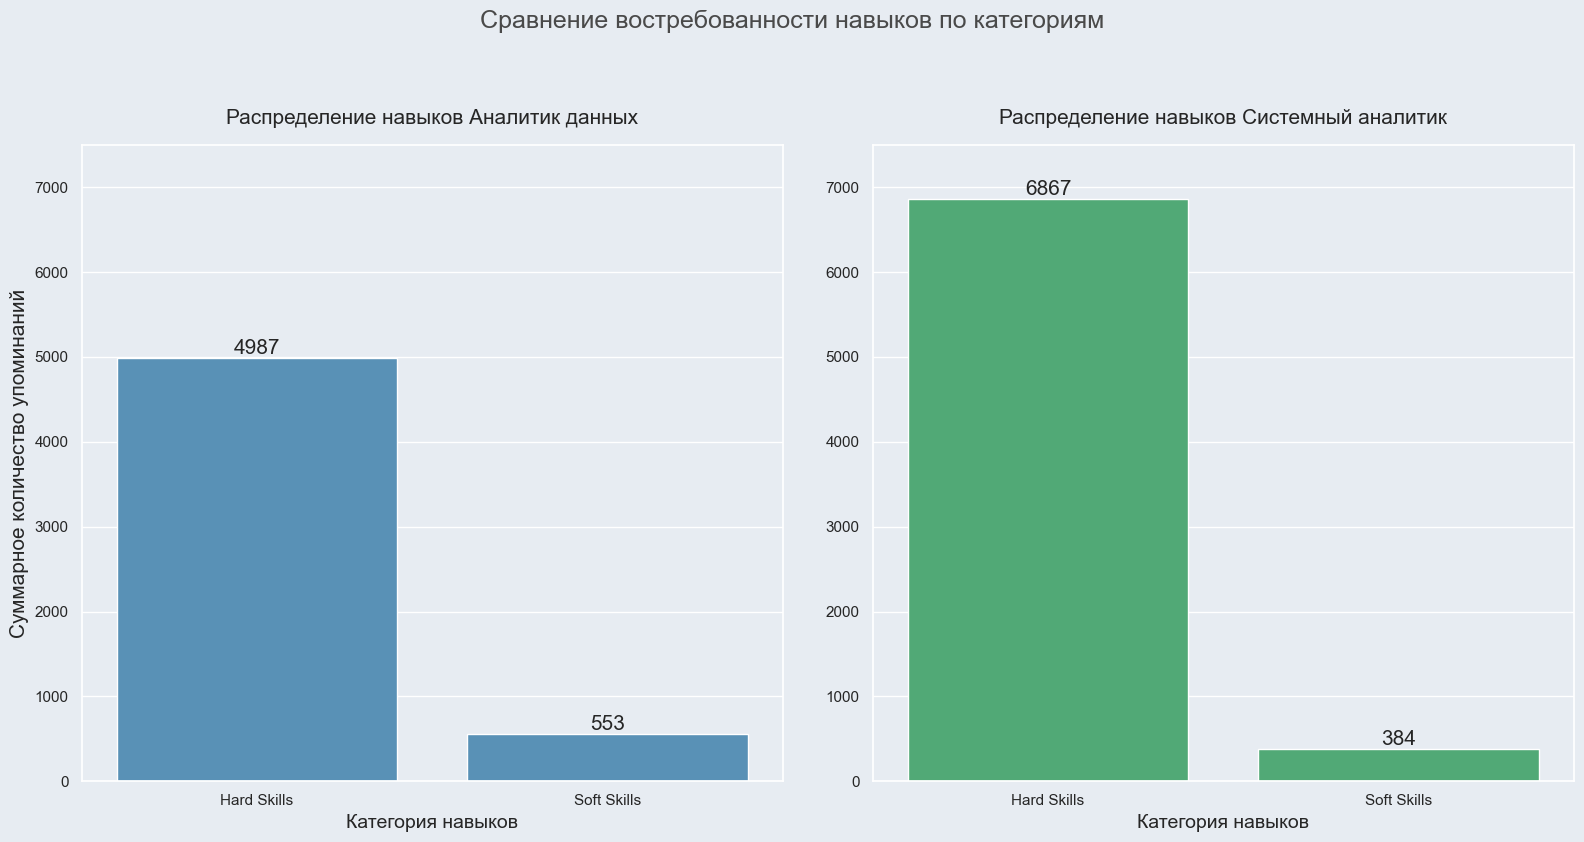

In [53]:
sns.set(rc={'axes.facecolor':'#e7ecf2', 'figure.facecolor':'#e7ecf2'}, 
        font_scale=1)

# Используем два способа
skills_da = (skills_da.assign(Категория=['Hard Skills' if x in hard_skills_da else 'Soft Skills' if x in soft_skills_da 
            else 'Other' for x in skills_da['Навык']]))

# и менее быстрйы через лямбду
skills_sa['Категория'] = skills_sa['Навык'].apply(
    lambda x: 'Hard Skills' if x in hard_skills_sa else 'Soft Skills' if x in soft_skills_sa else 'Other'
)

# Создаем сводные таблицы с суммой упоминаний по категориям
da_summary = (skills_da
            .query('Категория == ["Hard Skills","Soft Skills"]')
            .groupby('Категория')['Частота'].sum().reset_index())
sa_summary = (skills_sa.query('Категория == ["Hard Skills","Soft Skills"]')
            .groupby('Категория')['Частота'].sum().reset_index())


# Создаем фигуру с двумя подграфиками
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Список кортежей для итерации.
datasets = [
    (da_summary, "Аналитик данных",'Суммарное количество упоминаний'),  # Первый датафрейм, его название и y label
    (sa_summary, "Системный аналитик",' ')  # Второй датафрейм и его название
]

for i , (data, title, y_label) in enumerate(datasets):
    sns.barplot(data=data,
                x='Категория',
                y='Частота',
                ax=axes[i],
                color=palette[i])
    axes[i].set_title(f'Распределение навыков {title}', fontsize=15, pad=15)
    axes[i].set_xlabel('Категория навыков', fontsize=14)
    axes[i].set_ylabel(f'{y_label}', fontsize=15)
    axes[i].bar_label(axes[i].containers[0], fmt='%.0f', fontsize=15)
    axes[i].set_ylim(0,7500) #share y


# Общие настройки
plt.suptitle('Сравнение востребованности навыков по категориям', fontsize=18, y=1.05, color='#4a4a4a')
plt.tight_layout()
plt.show()

**Сравнительный анализ соотношения hard и soft skills в вакансиях для аналитиков**


**Аналитики данных**

Технические навыки (hard skills) составляют подавляющее большинство (около 90% ) всех упоминаний в описаниях вакансий аналитиков данных.
Мягкие навыки (Soft skills) упоминаются реже (примерно 9–10% ), они всё равно играют важную роль и будут очень важны для эффективного взаимодействовия с бизнесом, интерпретации данных и умении доносить выводы до не-технической аудитории.

**Системные аналитики:**

Проф. Системного аналитика также требует глубоких технических знаний.Они составляют подавляющее большинство(около 95%) всех упоминаний в вакансиях.Несмотря на ещё меньшее число упоминаний, soft skills по схожей логике  важны, не только для взаимодействия внутри, но и как мостик между заказчиком и технической командой.

**Выводы:**

Предположу, что для старта карьеры критически важны hard skills, но для её развития - на первый план могут выйти soft skills , которые позволяют выделиться среди коллег, эффективно взаимодействовать в команде и брать на себя большую ответственность. 

<a id='sa_grade' a>

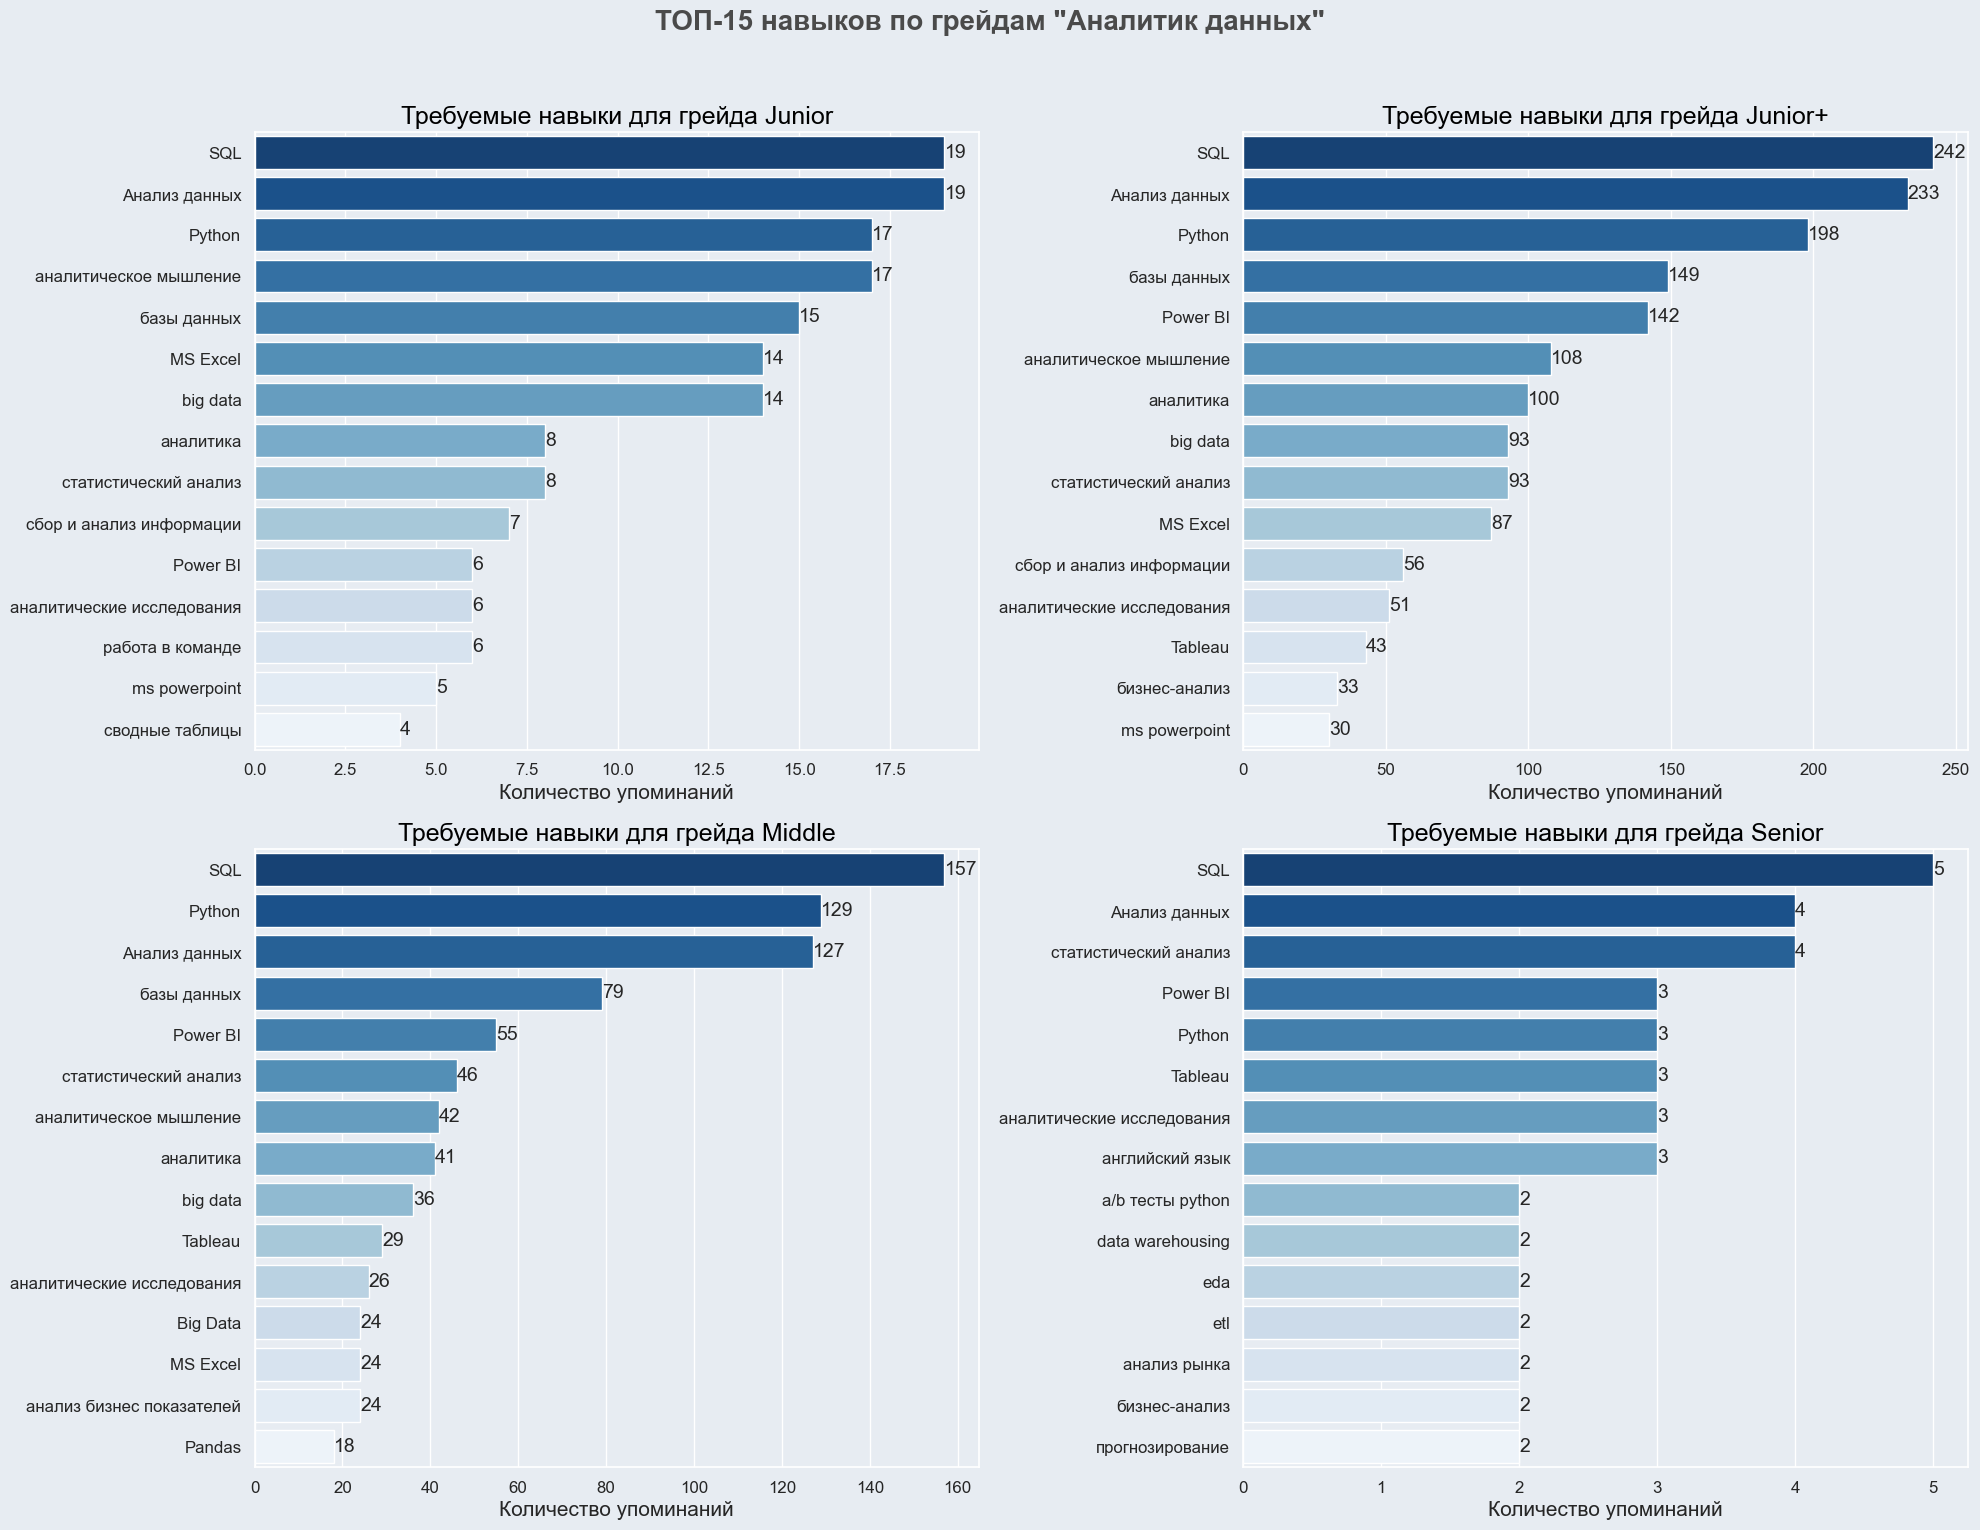

In [54]:

# Настройки стиля
sns.set(rc={'axes.facecolor':'#e7ecf2', 'figure.facecolor':'#e7ecf2'}, font_scale=1.1)

# Создаём фигуру
fig, axes = plt.subplots(2, 2, figsize=(20, 15), sharex=False)
axes = axes.flatten()  # чтобы удобнее обращаться к осям по одному индексу

# Функция для обработки данных
def process_skills(data, experience_level):
    mask = (da.key_skills_from_key_skills_field.notna()) & (da.experience == experience_level)
    words = ' '.join(da.loc[mask, 'key_skills_from_key_skills_field'].tolist()).strip().lower().split(',')
    word_counter = pd.DataFrame(Counter(words).most_common(40))
    word_counter.columns = ['word', 'cnt']
    word_counter.word = word_counter.word.str.strip()
  

    word_counter['word'] = word_counter['word'].replace(skill_mapping)

    return word_counter.groupby('word', as_index=False)['cnt'].sum().nlargest(15, 'cnt')

plt.suptitle('ТОП-15 навыков по грейдам "Аналитик данных"', 
                size=20, y=1.02, weight='bold', color='#4a4a4a')

# Уровни опыта
experience_levels = [
    ('Junior (no experince)', 'Требуемые навыки для грейда Junior', axes[0]),
    ('Junior+ (1-3 years)', 'Требуемые навыки для грейда Junior+', axes[1]),
    ('Middle (3-6 years)', 'Требуемые навыки для грейда Middle', axes[2]),
    ('Senior (6+ years)', 'Требуемые навыки для грейда Senior', axes[3])
]

# Построение графиков
for exp, title, ax in experience_levels:
    df = process_skills(data, exp)
    sns.barplot(data=df, y='word', x='cnt', palette='Blues_r', ax=ax)
    ax.set_title(title, size=18, color='black')
    ax.set_ylabel('')
    ax.set_xlabel('Количество упоминаний', size=15)
    
    for container in ax.containers:
        ax.bar_label(container, label_type='edge', size=14)

plt.tight_layout()
plt.show()

**Аналитики данных**

**Hard skills**

- **SQL** : Упоминается почти во всех вакансиях 
- **Python** конкурирует за первое место на всех грейдах, как основной язык программирования для обработки , анализа и автоматизации задач. 
- Инструменты визуализации : **Power BI и Tableau** доминируют в качестве инструментов для представления данных.
- **Excel** остаётся популярным инструментом, особенно на начальных этапах карьеры, но его значимость либо снижается, либо подразумевается  по мере роста уровня специалиста.

**Soft skills**

- **Аналитика и аналитическое мышление** отнесу к основным софт скилам , которые ждут работодатели.Понятная интерпретация, грамотная речь и простые практические рекомандации без сложных технических терминов, как очень важный навык хорошего аналитика.

**Статистикий анализ**
- Мы уже говорили, что статистическое подтверждение выдвигаемых гипотез важнейшая часть работы аналитика.



**Общий вывод**

Надо сказать, что  на всех уровнях стек практически не отличается. Работа с большими данными, их извлечение, обработка, визуализация и интерпретация подразумевает вполне конкретный набор технических навыков. Мягкие же могут иметь большую приоритетность с поправкой на должностные обязанности.


<a id='da_grade' a>

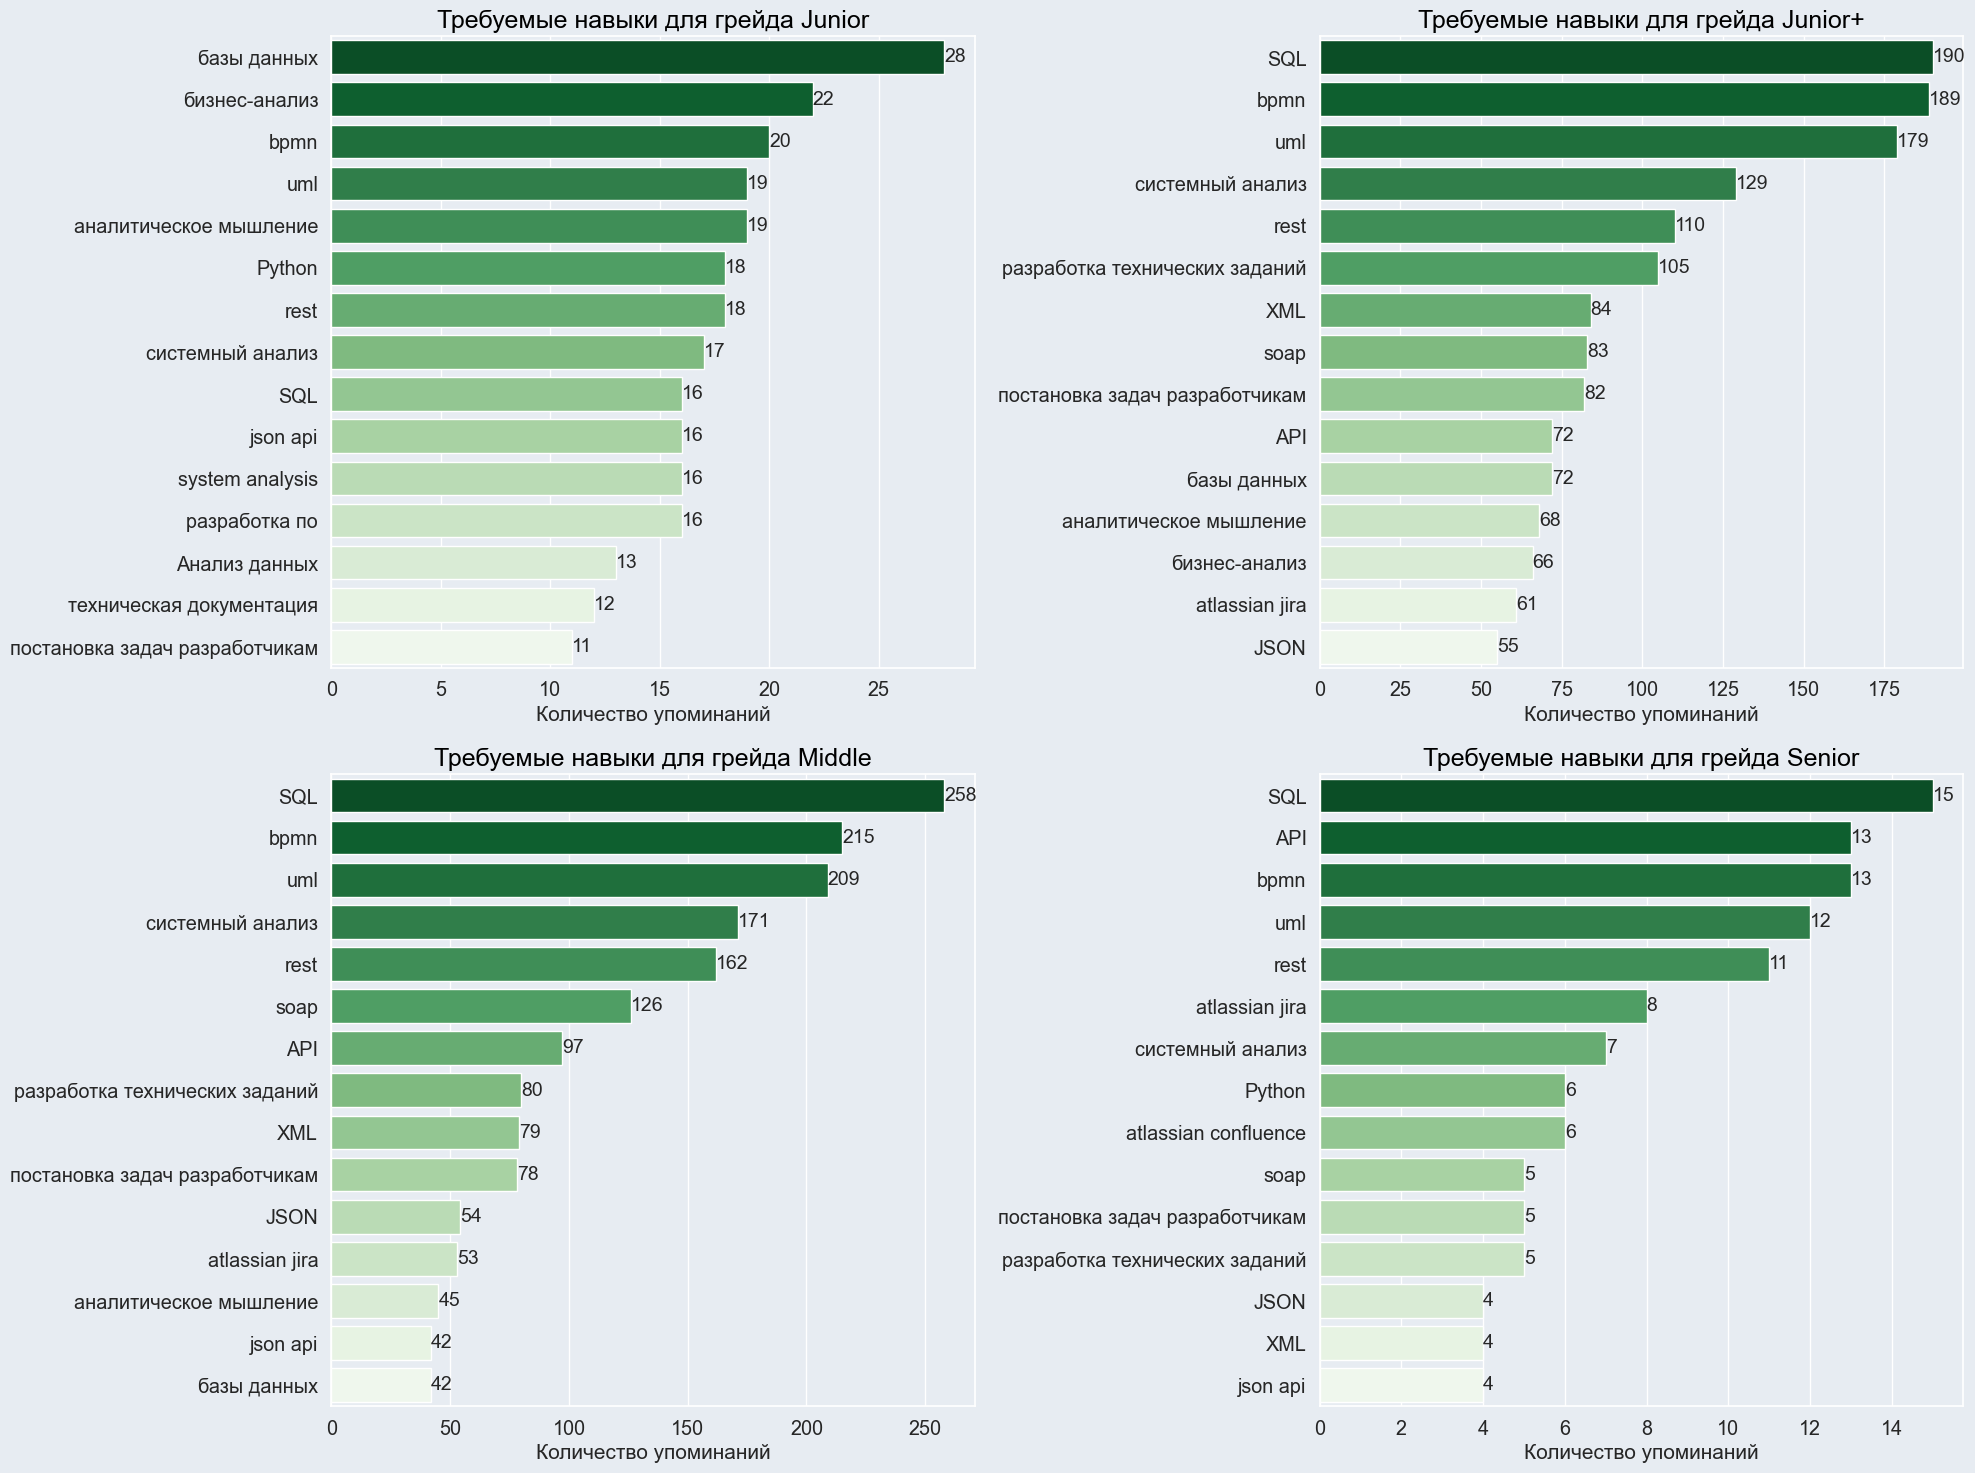

In [55]:
# Настройки стиля
sns.set(rc={'axes.facecolor':'#e7ecf2', 'figure.facecolor':'#e7ecf2'}, font_scale=1.3)

# Создаём фигуру
fig, axes = plt.subplots(2, 2, figsize=(20, 15), sharex=False)
axes = axes.flatten()  # чтобы удобнее обращаться к осям по одному индексу

# Функция для обработки данных
def process_skills(data, experience_level):
    mask = (sa.key_skills_from_key_skills_field.notna()) & (sa.experience == experience_level)
    words = ' '.join(sa.loc[mask, 'key_skills_from_key_skills_field'].tolist()).strip().lower().split(',')
    word_counter = pd.DataFrame(Counter(words).most_common(40))
    word_counter.columns = ['word', 'cnt']
    word_counter.word = word_counter.word.str.strip()

    

    word_counter['word'] = word_counter['word'].replace(skill_mapping)

    return word_counter.groupby('word', as_index=False)['cnt'].sum().nlargest(15, 'cnt')

# Уровни опыта
experience_levels = [
    ('Junior (no experince)', 'Требуемые навыки для грейда Junior', axes[0]),
    ('Junior+ (1-3 years)', 'Требуемые навыки для грейда Junior+', axes[1]),
    ('Middle (3-6 years)', 'Требуемые навыки для грейда Middle', axes[2]),
    ('Senior (6+ years)', 'Требуемые навыки для грейда Senior', axes[3])
]

# Построение графиков
for exp, title, ax in experience_levels:
    df = process_skills(data, exp)
    sns.barplot(data=df, y='word', x='cnt', palette='Greens_r', ax=ax)
    ax.set_title(title, size=18, color='black')
    ax.set_ylabel('')
    ax.set_xlabel('Количество упоминаний', size=15)
    
    for container in ax.containers:
        ax.bar_label(container, label_type='edge',size=14)

plt.tight_layout()
plt.show()

**Системные аналитки**

**Hard skills**

Системные аналитики любого уровня должны знать SQL , UML и BPMN — эти инструменты необходимы для моделирования процессов и работы с данными. Однако стоит отметить, что SQL начинает доминировать только с позиций Junior+ . Среди вакансий без опыта он выходит за пределы топ-навыков, что может быть связано с более базовым уровнем требований.
Важно также понимание протоколов REST/SOAP и форматов XML/JSON , используемых при описании API и интеграций.

**Soft skills**

Среди мягких навыков выделяются аналитическое мышление и бизнес-анализ , которые требуются примерно в четверти вакансий.
На уровне Middle+ возрастает значимость умения писать ТЗ и ставить задачи разработчикам — ключевые навыки для взаимодействия с командой.

 Atlassian Jira встречается в 61% вакансий, что делает её фактически обязательным навыком.

## Обще выводы и рекомендации

Были проанализированы два датасета с вакансиями для <span style="color:#42b874">**Системных аналитков**</span> VS - <span style="color:#4994c6">**Аналитиков данных**</span>
Период исследования: февраль-июль 2024 года. В ходе работы были достигнуты поставленные цели исследования, что нашло отражение в представленных таблицах, диаграммах и графиках.

**** 

### 1. Предлагаемая зарплата

**Аналитики данных**

- **Junior** - Требования: 0–1 год опыта. Типичный диапазон: 60–90 тыс. руб.
- **Junior+** -  Требования: 1-2 года опыта. Типичный диапазон: 90–120 тыс. руб.
- **Middle**  - Требования: 3+ лет опыта. Типичный диапазон: 160–250 тыс. руб.
- **Senior** - Требования: 6+ лет опыта. Типичный диапазон: 200–280 тыс. руб.

**Системные аналитки**

- **Junior** - Требования: 0–1 год опыта. Типичный диапазон: 60–80 тыс. руб.
- **Junior+** -  Требования: 1-2 года опыта. Типичный диапазон: 110–180 тыс. руб.
- **Middle**  - Требования: 3+ лет опыта. Типичный диапазон: 190–290 тыс. руб.
- **Senior** - Требования: 6+ лет опыта. Типичный диапазон: 250–370 тыс. руб.


Системные аналитики во всех грейдах получают более высокие зарплаты, чем их коллеги-аналитики данных. Разница особенно заметна на уровнях **Middle** и **junior+**:

- junior+: +20-60 тыс. руб. в пользу системных аналитиков (90–120 тыс. против 110–180 тыс.).
- Middle: +30–40 тыс. руб. в пользу системных аналитиков (190–290 тыс. против 160–250 тыс.).

Сравнивть Senior'ов будет некорректо из за недостаточной выборки необходимой для исследования.

`Динамика роста оклада`

Для обеих профессий характерен двукратный рост зарплат при переходе между грейдами:

- **Аналитики данных** **Junior → Middle** = +100–130% (с 60–90 тыс. до 160–250 тыс. руб.).
- **Системные аналитики: Junior → Middle** = +150–200% (с 60–80 тыс. до 190–290 тыс. руб.) .

У системных аналитиков более выражен скачок на уровне Junior(с 60–90 тыс.) → Junior+ (110–180 тыс. руб.), что может указывать на быстрый рост ценности специалистов с минимальным опытом.

`Совет для соискателей:`
- Cверяйтесь с реальными вилками при составлении резюме и при поиске ваканский.
- Преодоление барьера с комерческим опытом в один год даст качественный рост заработной платы уже на уровне Junior+, в особенности для системных аналитиков.

---

### 2. Условия работы

**График работы**

Практически все компании предлагают полную занятность. Случаи с проектной или частичной занятостью единичны. Всего 29 вакансий для системников без опыта предлагают стажировку, в то время как у data-аналитиков возможностей постажироваться ещё меньше при 15 вакансиях.Но это во многом связано с небольшим количеством ваканский для входного уровня.

**Формат работы**

**Аналитики данных**

- Junior / Junior+

Среди вакансий для Junior и Junior+ преобладает офисный формат — около 83% и всего 9% вакансий с удалёнкой, что связано с необходимостью адаптации и интеграции новичков в команду.

- Middle / Senior

Уже прослеждиваются тенденция к гибкости : среди Middle-специалистов доля удалённых позиций составляет 25%. У Senior-аналитиков этот показатель ещё выше — 35%, хотя стоит учитывать небольшую выборку.

Тренд очевиден: с ростом опыта аналитики получают больше доверия от работодателей и могут рассчитывать на более комфортные и гибкие условия работы.

**Системные аналитки**

- Junior / Junior+

Около 32% вакансий для Junior и Junior+ допускают возможность удалённой работы — это довольно высокий показатель для начальных уровней.Также стоит отметить, что 7% позиций без опыта предлагают гибкий график — вероятно, такие варианты рассчитаны на студентов или совместителей.

- Middle / Senior

Для опытных специалистов ситуация меняется, но не кардинально: примерно 36% вакансий для Middle и Senior предусматривают удалённый формат. Это увеличение оказалось относительно небольшим.

**Сравнение и выводы**

Если сравнить с данными по data-аналитикам , где доля удалённых вакансий с ростом опыта заметно возрастает (от 9% у Junior до 25% у Middle), то у системных аналитиков эта тенденция выражена гораздо слабее. Увеличение доступности удалённой работы от Junior к Senior составляет всего 4 процентных пункта , что выглядит скромно.

Однако **важно отметить**: несмотря на отсутствие значительного роста удалёнки с повышением опыта , доля удалённых вакансий у системных аналитиков на всех уровнях квалификации значительно выше и составляет около трети всех вакансий !

---
### 3. Работодатели


Рынок вакансий для **data-аналитиков**  сегментирован по отраслям. Безусловным лидером для всех уровней является экосистема СБЕР, предлагающая 243 позиции - почти втрое больше, чем ближайшие конкуренты. Основной спрос сосредоточен в четырех ключевых секторах: 
- Финансовом (банки и финтех)
- ИТ-интеграции
- Медиаиндустрия 
- Ритейле (особенно e-commerce).

Рынок **системных аналитиков** имеет заметные отличия. Основной спрос формируют:

- Финансовый сектор (банки, финтех) - лидер по количеству вакансий

- Крупные ИТ-компании (Т1, Aston) 

В отличие от data-аналитиков, здесь доминируют интеграторы и разработчики ПО. Экосистемные игроки представлены минимально (Сбер - всего 2 вакансии).Практически отсутствуют вакансии в ритейле и e-commerce, характерные для data-аналитиков. У **системников** комерческий опыт имеет большее значние - даже крупные работодатели редко рассматривают junior-специалистов.

### 4. Навыки

**Аналитики данных**

  Для аналитика данных ключевыми остаются SLQ, Python, Power BI — без них не обходится ни одна вакансия. Python должен усиливать позиции, особенно в компаниях, где нужна сложная обработка данных  и работа с большими данными. Статистика и A/B-тесты важны, но упоминаются реже и требуются как дополнение к основным техническим навыкам.

Идеальный профиль: SQL + BI-инструмент + базовый Python с пониманием статистики, (умеющий работать с большими данными, в офисе , имеющий более года комерческого опыта и с зарплатными ожиданями в диапазоне 90-110.т.р. - наш идеальный кандидат :). Остальное — в зависимости от специализации (маркетинг, продукт, финансы).

**Системные аналитки**

   Топ-навыковы системных аналитиков показывают, что профессия сочетает в себе как техническую экспертизу SQL, базы данных , протоколы: REST/SOAP/XML/JSON), так и soft skills (аналитическое мышление, постановка задач).
При этом, в отличие от data-аналитиков, где доминируют инструменты вроде Python или Excel, системные аналитики во многом сосредоточены на методологиях моделирования процессов и документирования требований.

Наш идеальный кандидат — это метафорический переводчик между  бизнесом и разработкой. Знает SQL, UML, BPMN и REST API и умеет писать ТЗ так, чтобы их читали, а не игнорировали.
   


[В начало](#pre)